In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
os.chdir("/accounts/projects/jchayes/commnotes/analysis")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import statsmodels.formula.api as smf
import statsmodels.api as sm


from src.data_loader import *
from src.analysis import *
from src.visualization import *
from src.visualization import (
    _C_BLUE, _C_ORANGE, _C_EVENT, _C_ZERO, _C_LIGHT, _C_PURPLE, _C_AMBER,
    _MUTED_PALETTE,
    _FONT_LEGEND, _FONT_LABEL, _FONT_TITLE, _FONT_TICK, _FONT_ANNOT,
    _setup_ax, _finalize, apply_pnas_style,
)
from src.utils import *

In [5]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
PAPER_DATA_URL = "https://raw.githubusercontent.com/trenault/CommunityNotes/main/database_replication.csv"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"

WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


max_date = "2023-06-01"

In [6]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X
# I only kept the following columns "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2022-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorzation 
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)

history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
paper_df = pd.read_csv(PAPER_DATA_URL, dtype={'tweet_id': str})

# The following df is notes with corresponding topics. Topics are modelled by the X topic modeling algorithm.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv")


notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_3938329/2332541645.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Loading weekly outputs: 100%|██████████| 84/84 [01:09<00:00,  1.21it/s]
/tmp/ipykernel_3938329/2332541645.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


In [7]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

In [8]:
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

Loading weekly outputs:   0%|          | 0/44 [00:00<?, ?it/s]

Loading weekly outputs: 100%|██████████| 44/44 [00:02<00:00, 15.41it/s]

note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [9]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})
note_df_full_2025 = note_df_full_2025.rename(columns={"internalNoteFactor1": "noteFactor1", "internalNoteIntercept": "noteIntercept"})

In [10]:
rollout_date = pd.to_datetime("2022-10-01")

In [11]:
# get one cohort of legacy raters who were active before rollout date
legacy_users = ratings_df[ratings_df['createdAtDate'] < rollout_date]['raterParticipantId'].unique()

# get one cohort of new raters who joined between Oct. 2022 and Jan. 2023
new_users = ratings_df[(ratings_df['createdAtDate'] >= rollout_date) & (ratings_df['createdAtDate'] < pd.to_datetime("2023-01-01"))]['raterParticipantId'].unique()
new_users = [user for user in new_users if user not in legacy_users]

In [12]:
len(legacy_users), len(new_users)

(1202, 7177)

In [13]:
# Also read in LLM modelled-topics
notes_df_llms = pd.read_csv("/accounts/projects/jchayes/commnotes/notes_llm_topic.csv")

# Latent Factor Distribution Shift


--- Slide 8 & 9: Factor Distribution Shifts ---


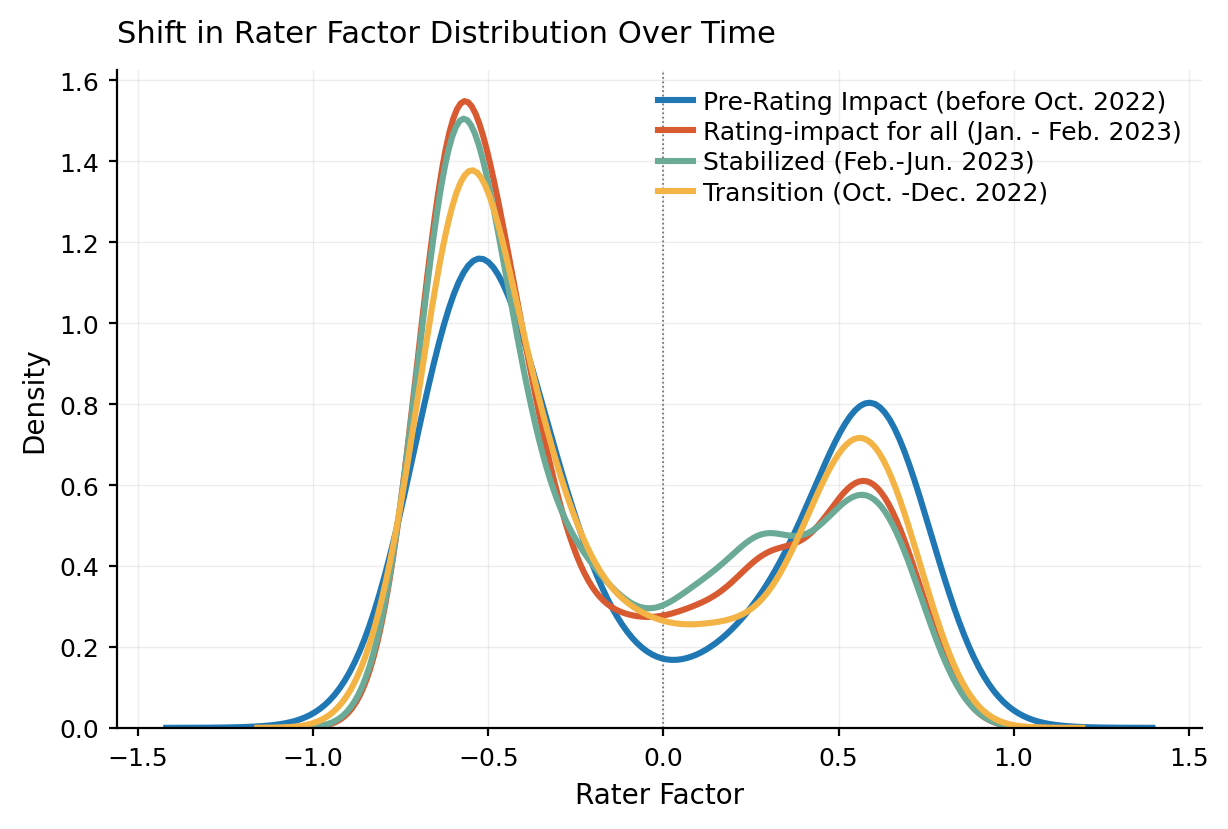

In [15]:
# Prepare common dataframes
latest_rater_factors = rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
rater_df['month_str'] = rater_df['week_dt'].dt.strftime('%Y-%m')
rater_df['phase'] = rater_df['month_str'].apply(assign_phase)

# Save the plot to final_code/figures
plot_factor_distribution_shifts(rater_df, 'raterFactor1', save_path='final_code/figures-pnas/rater_factor_distribution_shift_2022.png')


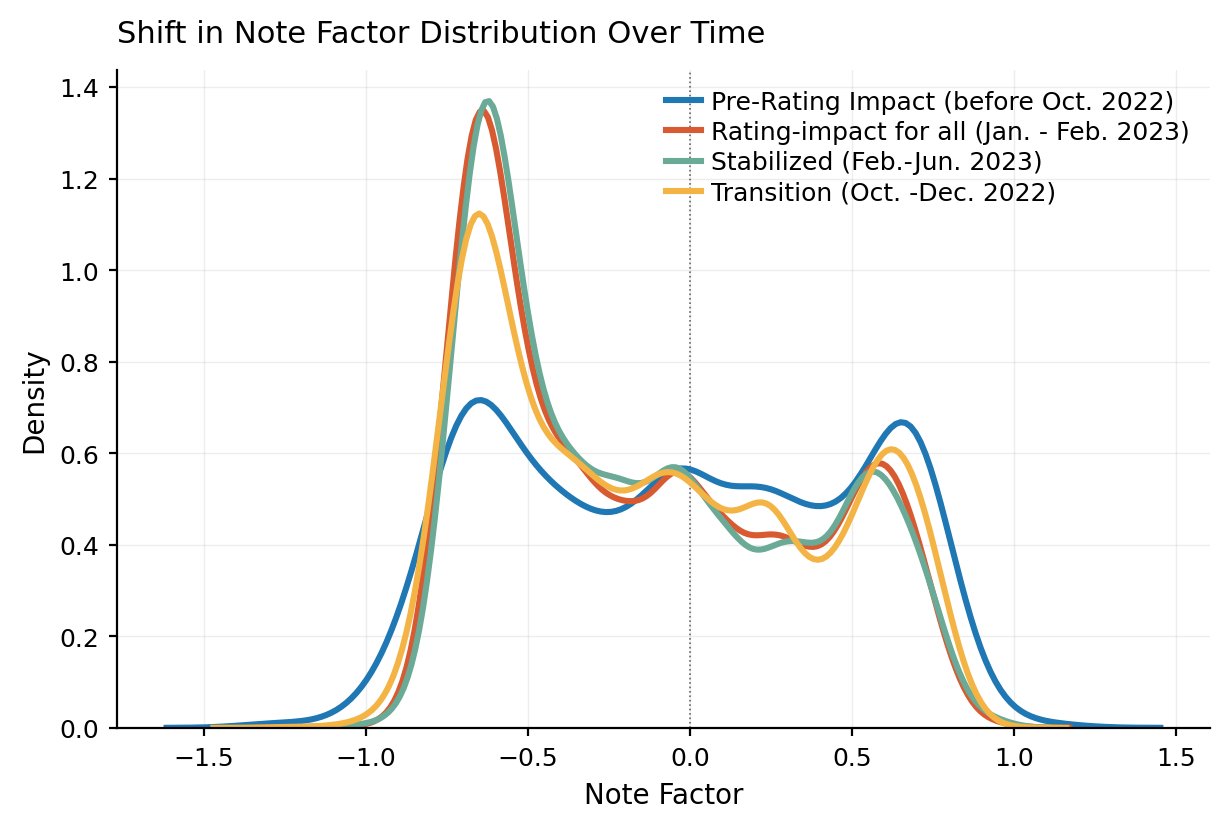

In [16]:
note_df_full['month_str'] = note_df_full['week_dt'].dt.strftime('%Y-%m')
note_df_full['phase'] = note_df_full['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(note_df_full, 'noteFactor1', save_path='final_code/figures-pnas/note_factor_distribution_shift_2022.png')

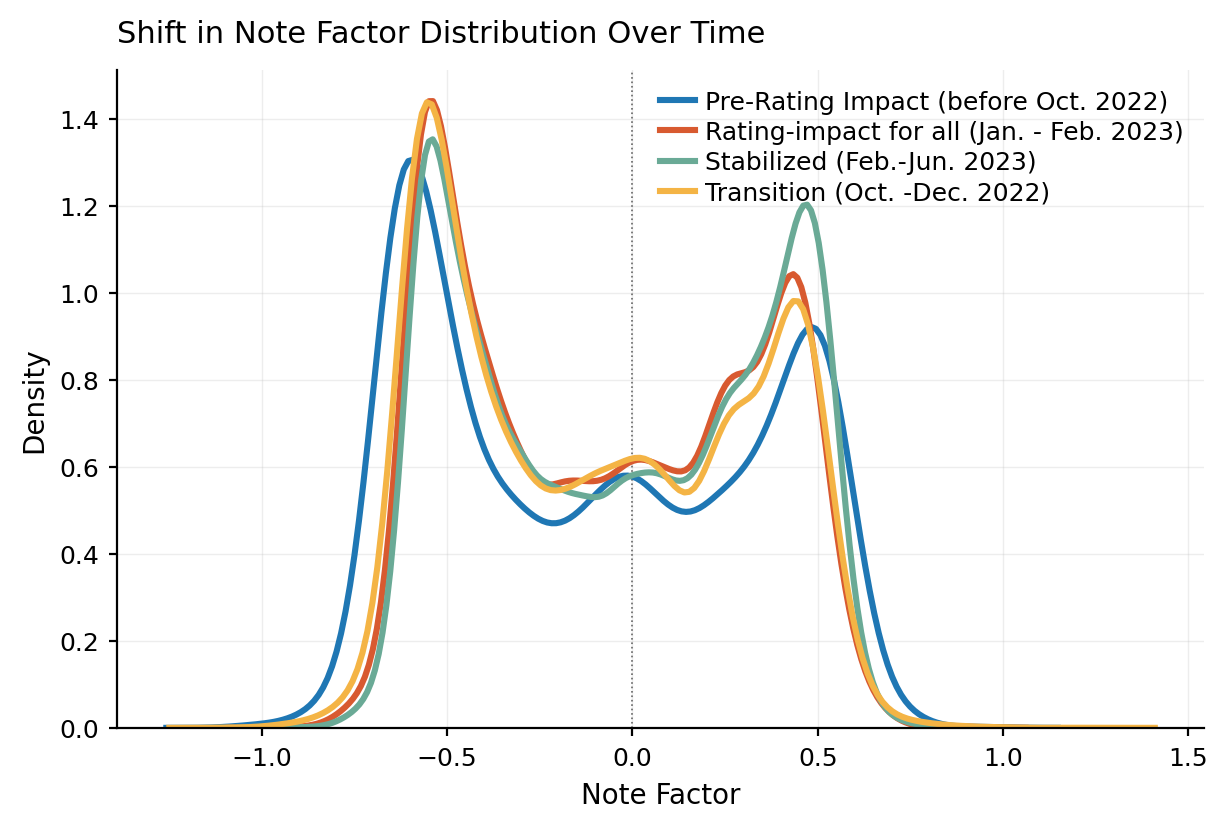

In [17]:
note_df_full_2025['month_str'] = note_df_full_2025['week_dt'].dt.strftime('%Y-%m')
note_df_full_2025['phase'] = note_df_full_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(note_df_full_2025, 'noteFactor1', save_path='final_code/figures-pnas/note_factor_distribution_shift_2025.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_3838238/2362160408.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3838238/2362160408.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


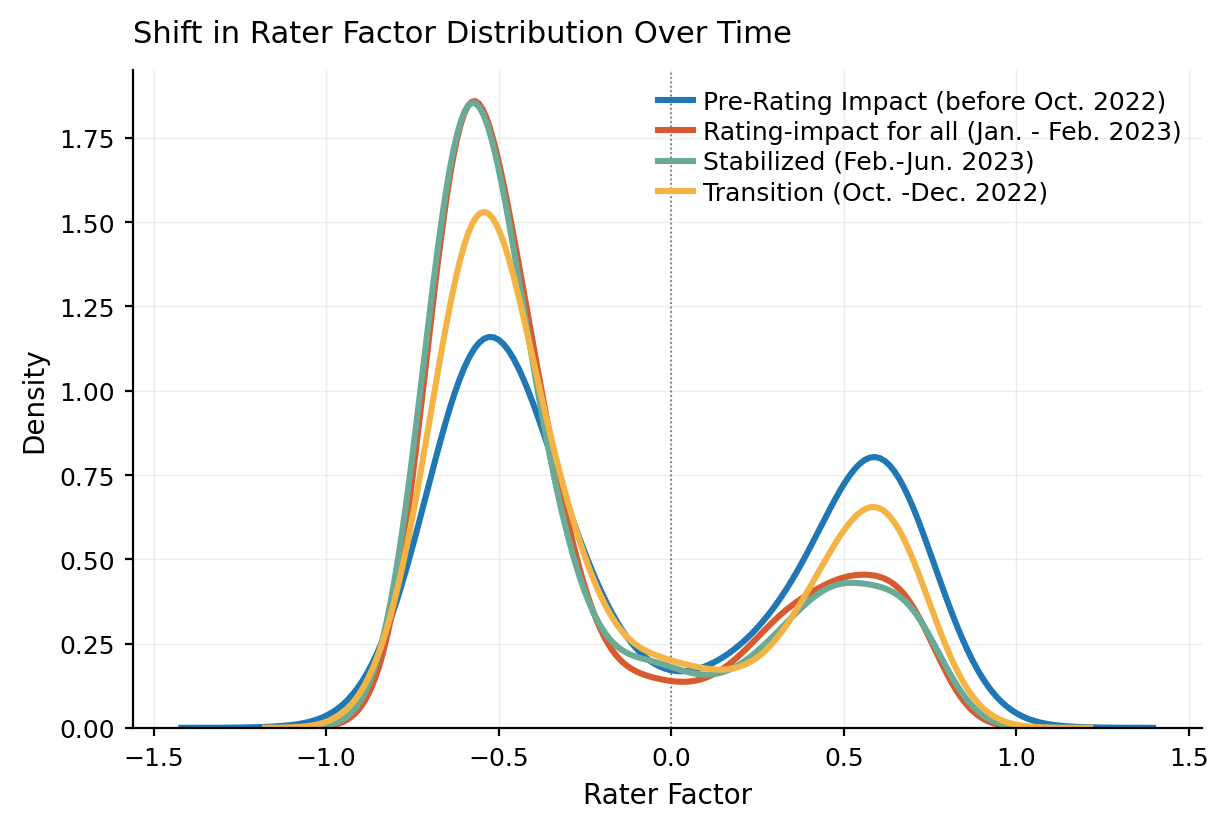

In [18]:
legacy_rater_df = rater_df[rater_df['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df['month_str'] = legacy_rater_df['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df['phase'] = legacy_rater_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df, 'raterFactor1', save_path='final_code/figures-pnas/rater_factor_distribution_shift_2022_legacy.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_3838238/2640726234.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3838238/2640726234.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


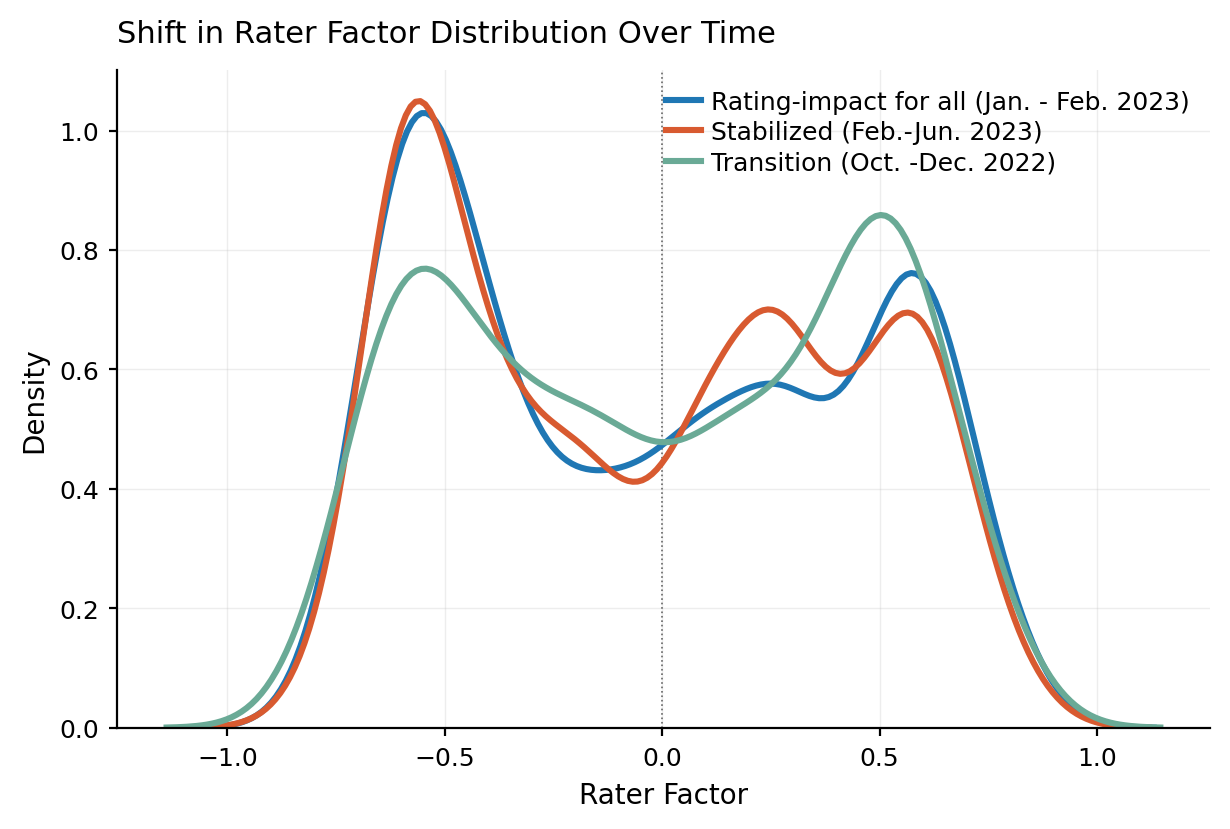

In [19]:
new_user_df = rater_df[rater_df['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_user_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_user_df['month_str'] = new_user_df['week_dt'].dt.strftime('%Y-%m')
new_user_df['phase'] = new_user_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_user_df, 'raterFactor1', save_path='final_code/figures-pnas/rater_factor_distribution_shift_2022_new.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_3838238/3795121095.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3838238/3795121095.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


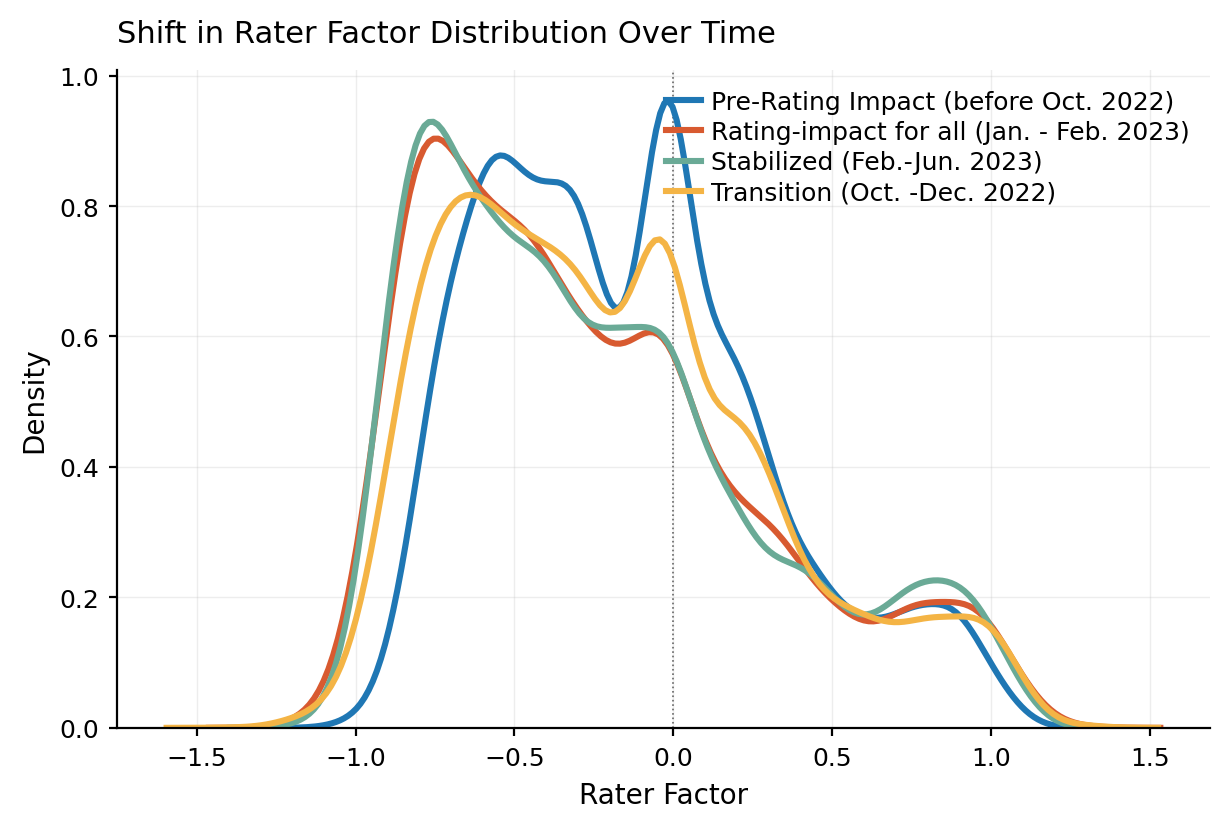

In [20]:
legacy_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df_2025['month_str'] = legacy_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df_2025['phase'] = legacy_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df_2025, 'raterFactor1', save_path='final_code/figures-pnas/rater_factor_distribution_shift_2025_legacy.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_3838238/3356940883.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_3838238/3356940883.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


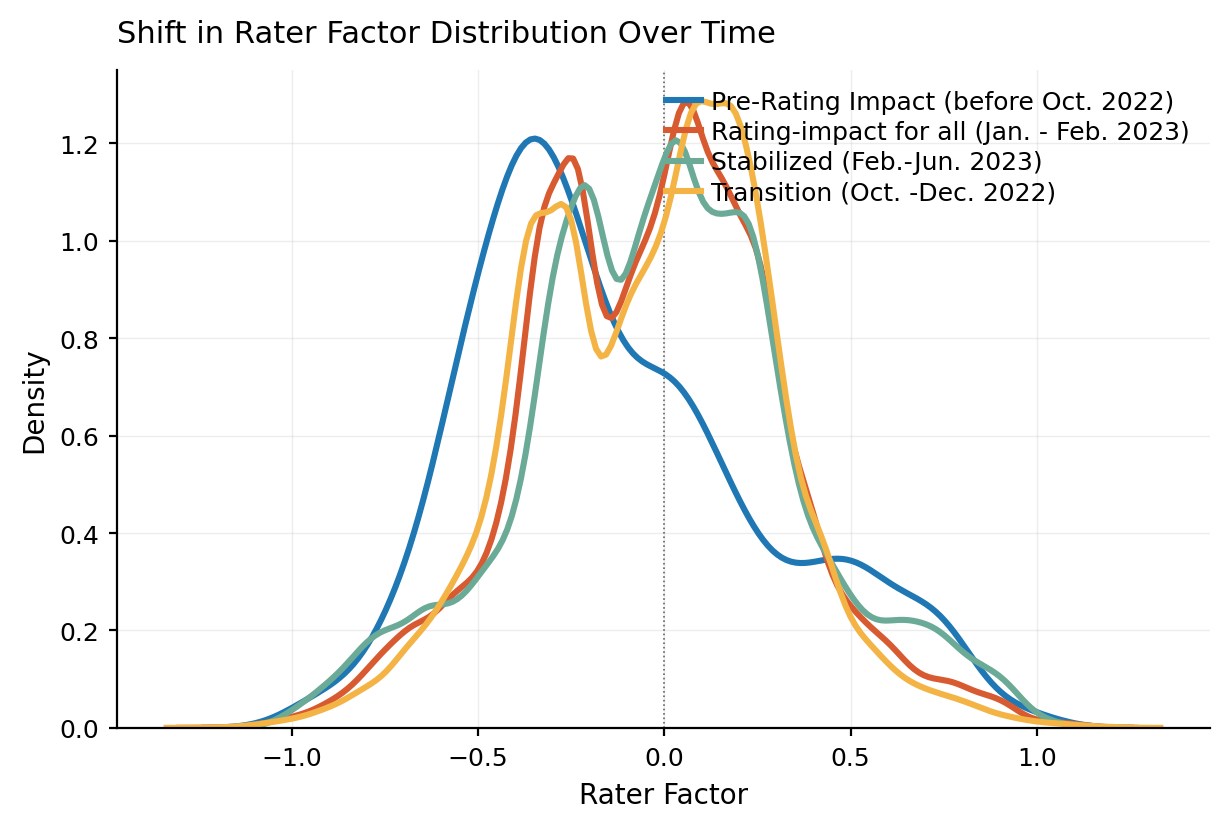

In [21]:
new_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_rater_df_2025['month_str'] = new_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
new_rater_df_2025['phase'] = new_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_rater_df_2025, 'raterFactor1', save_path='final_code/figures-pnas/rater_factor_distribution_shift_2025_new.png')

In [22]:
# measure the difference in factor shift for legacy vs. new users between oct. 1, 2022 to jan. 1, 2023
def compute_factor_shift(df, user_list, factor_col):
    df = df.copy()
    df['week_dt'] = pd.to_datetime(df['week_dt'])

    # First factor after Oct 1, 2022
    first_df = (
        df[
            (df['raterParticipantId'].isin(user_list)) &
            (df['week_dt'] > pd.Timestamp('2022-10-01'))
        ]
        .sort_values('week_dt')
        .groupby('raterParticipantId', as_index=False)
        .first()
        [['raterParticipantId', factor_col]]
        .rename(columns={factor_col: 'first_factor'})
    )

    # First factor after Jan 1, 2023
    last_df = (
        df[
            (df['raterParticipantId'].isin(user_list)) &
            (df['week_dt'] > pd.Timestamp('2023-01-01'))
        ]
        .sort_values('week_dt')
        .groupby('raterParticipantId', as_index=False)
        .first()
        [['raterParticipantId', factor_col]]
        .rename(columns={factor_col: 'last_factor'})
    )

    # Merge and compute shift
    out = first_df.merge(last_df, on='raterParticipantId', how='inner')
    out['factor_shift'] = out['last_factor'] - out['first_factor']

    return out


In [23]:
legacy_shift_2022 = compute_factor_shift(rater_df, legacy_users, 'raterFactor1')
new_shift_2022 = compute_factor_shift(rater_df, new_users, 'raterFactor1')

In [24]:
legacy_shift_2025 = compute_factor_shift(rater_df_2025, legacy_users, 'raterFactor1')
new_shift_2025 = compute_factor_shift(rater_df_2025, new_users, 'raterFactor1')

In [25]:
len(legacy_shift_2025), len(new_shift_2025)

(1147, 4323)

In [26]:
# permutation test for whether legacy users and different factor shift than new users
def perm_test(x, y, n_perm=10_000, seed=0, stat=np.mean):
    x = np.asarray(x)
    y = np.asarray(y)

    obs = stat(x) - stat(y)

    combined = np.concatenate([x, y])
    n_x = len(x)

    rng = np.random.default_rng(seed)
    perm = np.empty(n_perm)

    for i in range(n_perm):
        rng.shuffle(combined)
        perm[i] = stat(combined[:n_x]) - stat(combined[n_x:])

    p = (np.abs(perm) >= np.abs(obs)).mean()
    return obs, p


In [27]:
perm_test(legacy_shift_2022['factor_shift'], new_shift_2022['factor_shift'])

(np.float32(-0.0523922), np.float64(0.0))

In [28]:
perm_test(legacy_shift_2025['factor_shift'], new_shift_2025['factor_shift'])

(np.float64(-0.09443889825136212), np.float64(0.0))

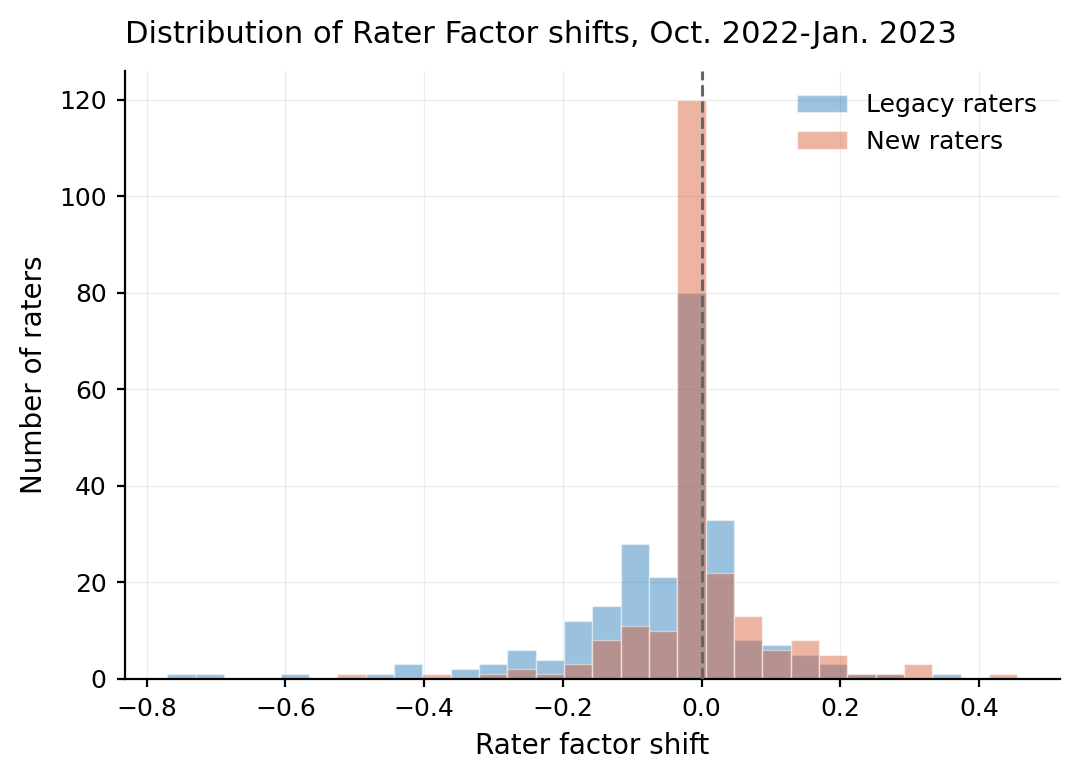

In [29]:
fig, ax = plt.subplots(figsize=(5.5, 4))

bins = np.linspace(
    min(
        legacy_shift_2022["factor_shift"].dropna().min(),
        new_shift_2022["factor_shift"].dropna().min(),
    ),
    max(
        legacy_shift_2022["factor_shift"].dropna().max(),
        new_shift_2022["factor_shift"].dropna().max(),
    ),
    31,
)

ax.hist(
    legacy_shift_2022["factor_shift"].dropna(),
    bins=bins,
    alpha=0.45,
    label="Legacy raters",
    color=_C_BLUE,
    edgecolor="white",
    linewidth=0.5,
)

ax.hist(
    new_shift_2022["factor_shift"].dropna(),
    bins=bins,
    alpha=0.45,
    label="New raters",
    color=_C_ORANGE,
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(
    0,
    color=_C_ZERO,
    linewidth=1.1,
    linestyle="--",
    zorder=4,
)

ax.legend(
    frameon=False,
    fontsize=_FONT_LEGEND,
    loc="upper right",
)

_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Rater factor shift",
    ylabel="Number of raters",
    title="Distribution of Rater Factor shifts, Oct. 2022-Jan. 2023",
    save_path="final_code/appendix-figures-pnas/rater_factor_shift_hist_2022.png",
)

In [30]:
legacy_mean = legacy_shift_2022["factor_shift"].mean()
new_mean    = new_shift_2022["factor_shift"].mean()
diff_means  = legacy_mean - new_mean

print(f"Legacy mean factor_shift: {legacy_mean:.6f}")
print(f"New mean factor_shift:    {new_mean:.6f}")
print(f"Difference (Legacy - New): {diff_means:.6f}")

Legacy mean factor_shift: -0.049158
New mean factor_shift:    0.003234
Difference (Legacy - New): -0.052392


In [31]:
rng = np.random.default_rng(0)
B = 10000  # bootstrap reps

x = legacy_shift_2022["factor_shift"].dropna().to_numpy()
y = new_shift_2022["factor_shift"].dropna().to_numpy()

# Bootstrap means for each group
x_boot_means = rng.choice(x, size=(B, x.size), replace=True).mean(axis=1)
y_boot_means = rng.choice(y, size=(B, y.size), replace=True).mean(axis=1)

x_mean = x.mean()
y_mean = y.mean()

x_ci_low, x_ci_high = np.percentile(x_boot_means, [2.5, 97.5])
y_ci_low, y_ci_high = np.percentile(y_boot_means, [2.5, 97.5])

print(f"Legacy mean factor_shift: {x_mean:.6f} (n={x.size})")
print(f"95% bootstrap CI:         [{x_ci_low:.6f}, {x_ci_high:.6f}]")
print()
print(f"New mean factor_shift:    {y_mean:.6f} (n={y.size})")
print(f"95% bootstrap CI:         [{y_ci_low:.6f}, {y_ci_high:.6f}]")


Legacy mean factor_shift: -0.049158 (n=237)
95% bootstrap CI:         [-0.066540, -0.032450]

New mean factor_shift:    0.003234 (n=218)
95% bootstrap CI:         [-0.010110, 0.016523]


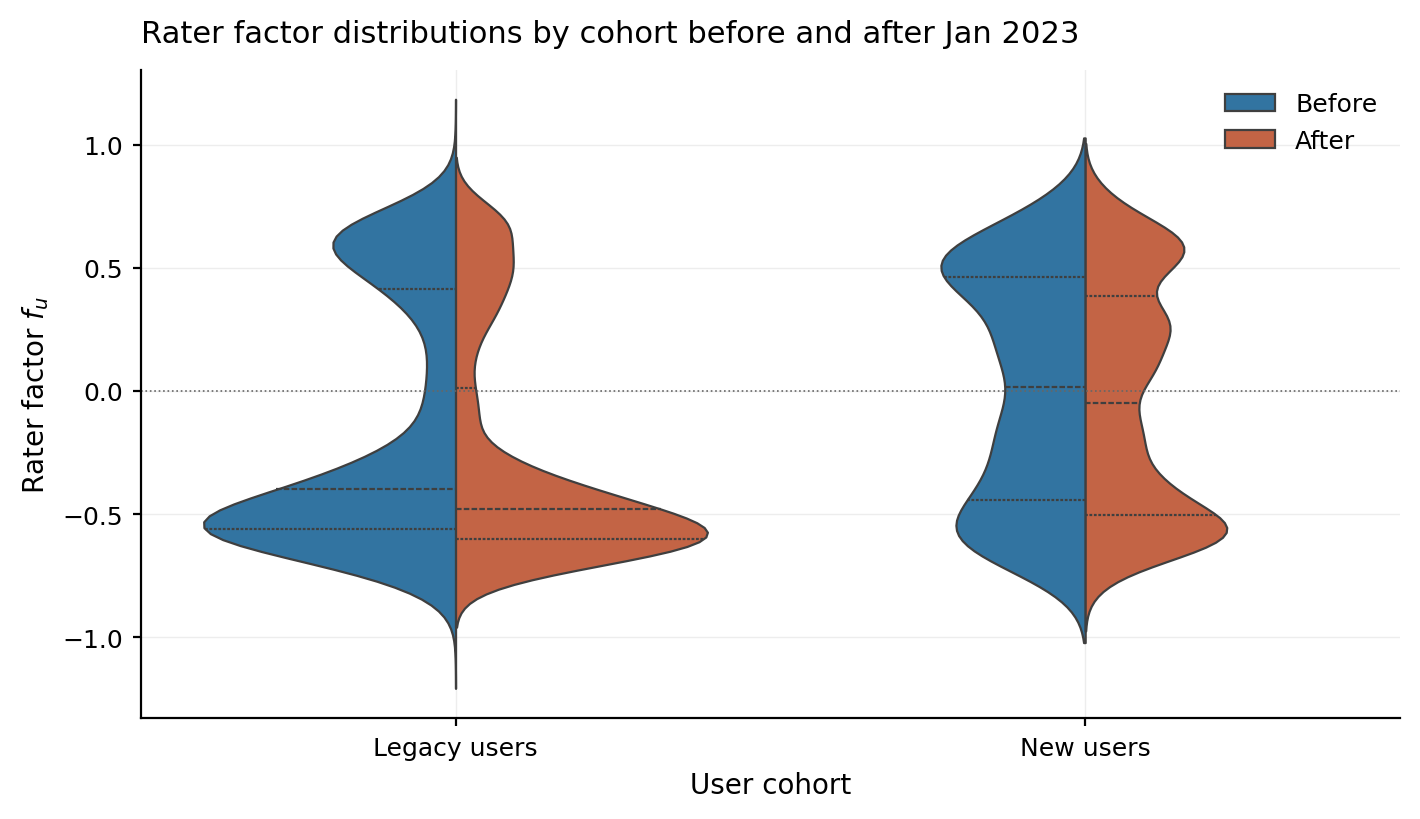

In [45]:
rater_df_legacy = rater_df[rater_df['raterParticipantId'].isin(legacy_users)].copy()
rater_df_new = rater_df[rater_df['raterParticipantId'].isin(new_users)].copy()

date_col = "week_dt"
cutoff = pd.Timestamp("2023-01-01")

rater_df_legacy[date_col] = pd.to_datetime(rater_df_legacy[date_col])
rater_df_new[date_col] = pd.to_datetime(rater_df_new[date_col])

rater_df_legacy["Cohort"] = "Legacy users"
rater_df_new["Cohort"] = "New users"
rater_df_legacy["Period"] = np.where(rater_df_legacy[date_col] < cutoff, "Before", "After")
rater_df_new["Period"] = np.where(rater_df_new[date_col] < cutoff, "Before", "After")

rater_df_cohort = pd.concat(
    [
        rater_df_legacy[["Cohort", "Period", "raterFactor1"]],
        rater_df_new[["Cohort", "Period", "raterFactor1"]],
    ],
    ignore_index=True,
).dropna(subset=["raterFactor1", "Period"])

apply_pnas_style()
fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.violinplot(
    data=rater_df_cohort,
    x="Cohort",
    y="raterFactor1",
    hue="Period",
    split=True,
    inner="quartile",
    palette=[_C_BLUE, _C_ORANGE],
    linewidth=0.8,
    ax=ax,
)

ax.axhline(0, color=_C_ZERO, linewidth=0.6, linestyle=":", zorder=1)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right", title=None)
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="User cohort",
    ylabel="Rater factor $f_u$",
    title="Rater factor distributions by cohort before and after Jan 2023",
    save_path="final_code/appendix-figures-pnas/rater_factor_violin_plot_2022.png",
)

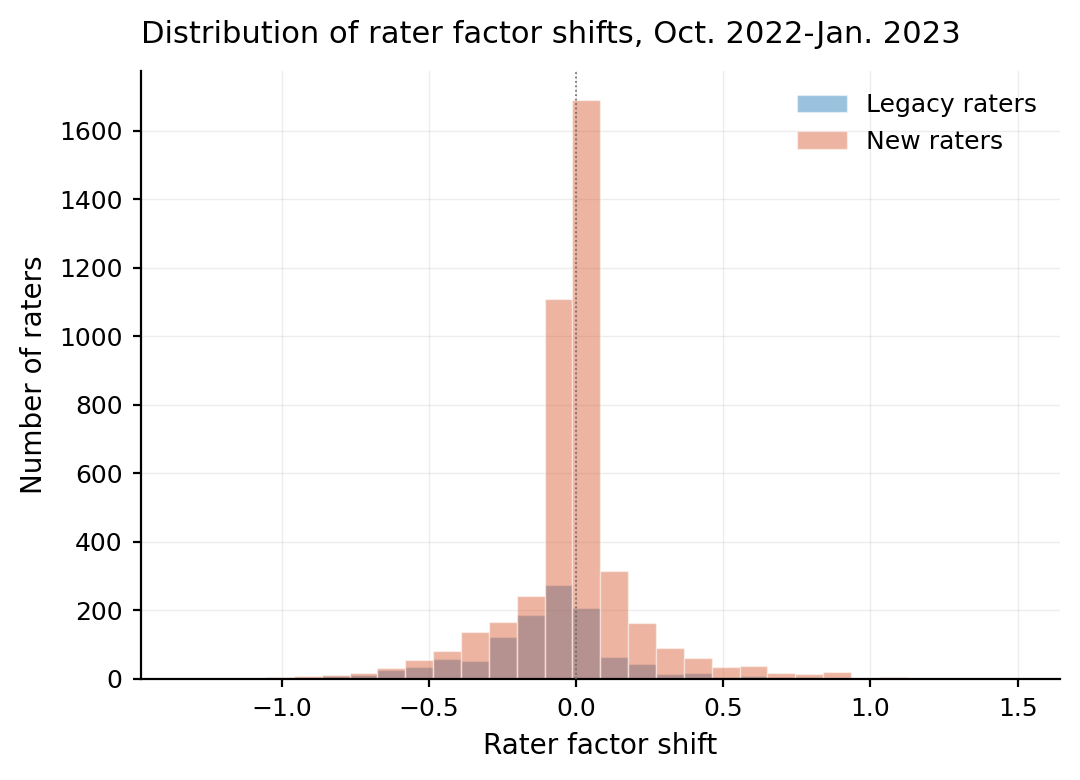

In [46]:
apply_pnas_style()
fig, ax = plt.subplots(figsize=(5.5, 4.0))

bins = np.linspace(
    min(
        legacy_shift_2025["factor_shift"].dropna().min(),
        new_shift_2025["factor_shift"].dropna().min(),
    ),
    max(
        legacy_shift_2025["factor_shift"].dropna().max(),
        new_shift_2025["factor_shift"].dropna().max(),
    ),
    31,
)

ax.hist(
    legacy_shift_2025["factor_shift"].dropna(),
    bins=bins,
    alpha=0.45,
    label="Legacy raters",
    color=_C_BLUE,
    edgecolor="white",
    linewidth=0.5,
)
ax.hist(
    new_shift_2025["factor_shift"].dropna(),
    bins=bins,
    alpha=0.45,
    label="New raters",
    color=_C_ORANGE,
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(0, color=_C_ZERO, linewidth=0.6, linestyle=":", zorder=4)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Rater factor shift",
    ylabel="Number of raters",
    title="Distribution of rater factor shifts, Oct. 2022-Jan. 2023",
    save_path="final_code/appendix-figures-pnas/rater_factor_shift_hist_2025.png",
)

# User-Note Alignment

In [14]:
def prepare_rating_factors_over_time_weekly(ratings_df, note_df, rater_df):
    # Add week column to ratings
    rater_df['week_dt'] = pd.to_datetime(rater_df['week_dt']).dt.normalize()
    note_df['week_dt'] = pd.to_datetime(note_df['week_dt']).dt.normalize()
    ratings_df['week_dt'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

    
    # Ensure note_df and rater_df also have 'week' column
    if 'week_dt' not in note_df.columns or 'week_dt' not in rater_df.columns:
        raise ValueError("note_df and rater_df must include a 'week' column for weekly merging.")
    
    ratings_df = ratings_df.sort_values(['week_dt'])
    note_df = note_df.sort_values([ 'week_dt'])
    rater_df = rater_df.sort_values(["week_dt"])

    # Merge_asof for note factors
    df = pd.merge_asof(
        ratings_df,
        note_df[['noteId', 'noteFactor1', 'noteIntercept', 'week_dt']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=False
    )

    # Ensure participant IDs are the same type (string is usually safest)
    rater_df["raterParticipantId"] = rater_df["raterParticipantId"].astype(str)
    df["raterParticipantId"] = df["raterParticipantId"].astype(str)
    
    # Merge with rater factors by raterParticipantId and week
    df = pd.merge_asof(
        left=df,
        right=rater_df[["raterParticipantId", "week_dt", "raterFactor1", 'raterIntercept']],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=False
    )

    # Convert labels
    df['helpful_binary'] = np.where(
        df['helpfulnessLevel'] == 'HELPFUL', 1,
        np.where(df['helpfulnessLevel'] == 'NOT_HELPFUL', 0, np.nan)
    )

    # # Clean up
    df = df.dropna(subset=['noteFactor1', 'raterFactor1', 'helpful_binary'])

    # Label for coloring
    df['vote_label'] = df['helpful_binary'].map({1: 'Helpful', 0: 'Not Helpful'})

    return df


# Prepare data
df_plot = prepare_rating_factors_over_time_weekly(ratings_df, note_df_full_2025, rater_df_2025)

In [15]:
df_plot.head()

,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,createdAtDate,week_dt,noteFactor1,noteIntercept,raterFactor1,raterIntercept,helpful_binary,vote_label
8611,1434773333359284224,8A2C6A27C1C09B68800C34B3C40F6B53DDB79378C3B038...,1659928769905,HELPFUL,2022-08-08 03:19:29.905,2022-08-08,-0.788607,0.135535,-0.581292,0.258333,1.0,Helpful
8613,1434660539813269513,8A2C6A27C1C09B68800C34B3C40F6B53DDB79378C3B038...,1659928802146,HELPFUL,2022-08-08 03:20:02.146,2022-08-08,-0.769889,0.126790,-0.581292,0.258333,1.0,Helpful
8670,1433290414082113538,6EEB94032F425636CC4475292D77127A69C350658077B4...,1660071103784,NOT_HELPFUL,2022-08-09 18:51:43.784,2022-08-08,0.523291,0.180286,-0.527169,0.278380,0.0,Not Helpful
8747,1545605017444524035,269CDF389F42840CCDA5444D6AB187440DD3FB91B60E79...,1660487460940,HELPFUL,2022-08-14 14:31:00.940,2022-08-08,-0.643198,0.223656,-0.694474,0.117382,1.0,Helpful
9145,1549795651797471233,65F687F3F0BE41BB456A883BA989742AB6F9566B731F75...,1660194229659,NOT_HELPFUL,2022-08-11 05:03:49.659,2022-08-08,0.278619,-0.015160,-0.726363,0.099647,0.0,Not Helpful


In [16]:
len(legacy_users)

1202

In [17]:
start = '2022-08-01'
end = '2023-01-01'

cutoff = '2022-10-01'

df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]

df_plot_legacy.shape

(329, 13)

Corr before: 0.7921
Corr after: 0.5251
Observed diff: -0.2670
P-value: 0.0090


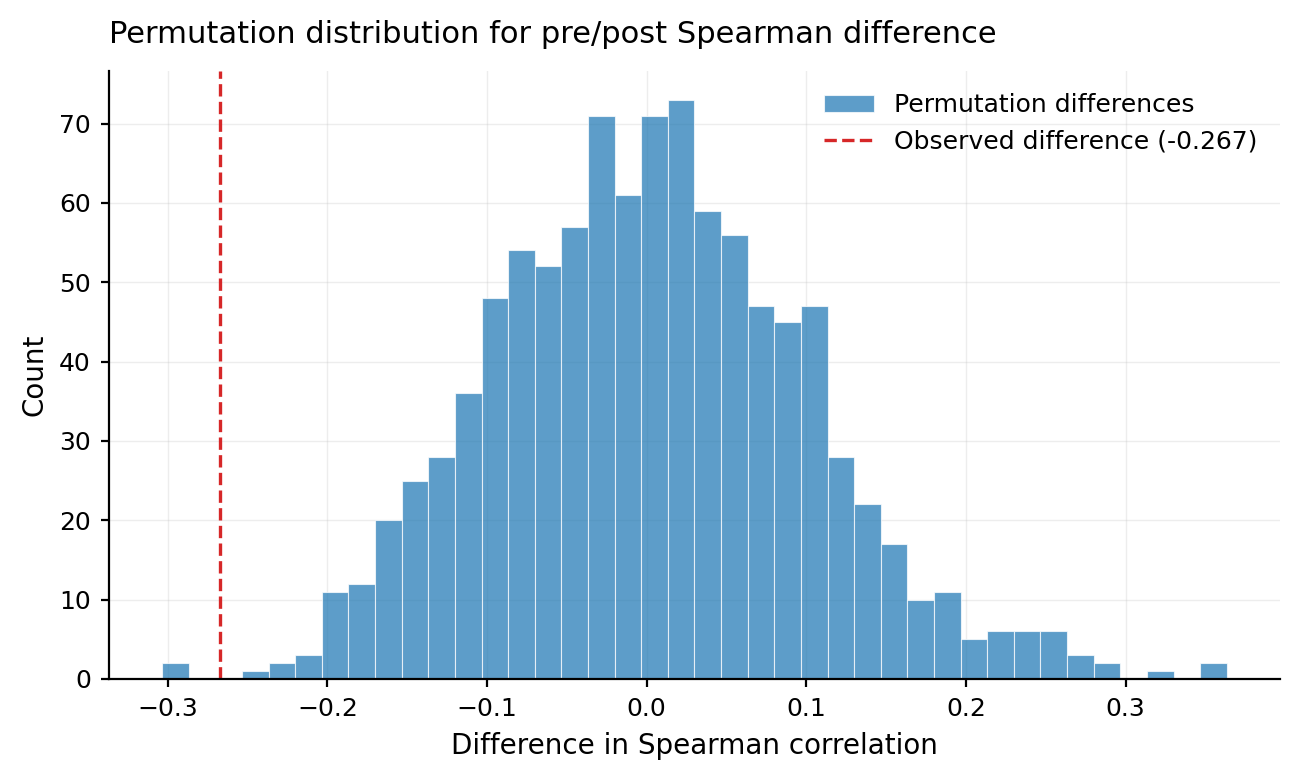

In [18]:
from scipy.stats import spearmanr

before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

corr_before = spearmanr(before['dot_product'], before['helpful_binary']).correlation
corr_after = spearmanr(after['dot_product'], after['helpful_binary']).correlation
observed_diff = corr_after - corr_before
print(f'Corr before: {corr_before:.4f}')
print(f'Corr after: {corr_after:.4f}')
print(f'Observed diff: {observed_diff:.4f}')

all_data = pd.concat([before, after]).reset_index(drop=True)
n_before = len(before)
perm_diffs = []

for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]

    c_before = spearmanr(perm_before['dot_product'], perm_before['helpful_binary']).correlation
    c_after = spearmanr(perm_after['dot_product'], perm_after['helpful_binary']).correlation
    perm_diffs.append(c_after - c_before)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')

apply_pnas_style()
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(
    perm_diffs,
    bins=40,
    color=_C_BLUE,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
    label="Permutation differences",
)
ax.axvline(
    observed_diff,
    color=_C_EVENT,
    linestyle="--",
    linewidth=1.2,
    label=f"Observed difference ({observed_diff:.3f})",
)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Difference in Spearman correlation",
    ylabel="Count",
    title="Permutation distribution for pre/post Spearman difference",
    save_path="final_code/figures-pnas/permutation_spearman.png",
)

In [19]:
df_plot_legacy['post'] = (df_plot_legacy['week_dt'] >= pd.to_datetime(cutoff)).astype(int)

model = smf.ols(
    'helpful_binary ~ dot_product + post + post:dot_product',
    data=df_plot_legacy
).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         helpful_binary   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     191.0
Date:                Tue, 26 May 2026   Prob (F-statistic):           2.16e-71
Time:                        15:33:10   Log-Likelihood:                -160.96
No. Observations:                 329   AIC:                             329.9
Df Residuals:                     325   BIC:                             345.1
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4937      0.039  

/tmp/ipykernel_3938329/1525246282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


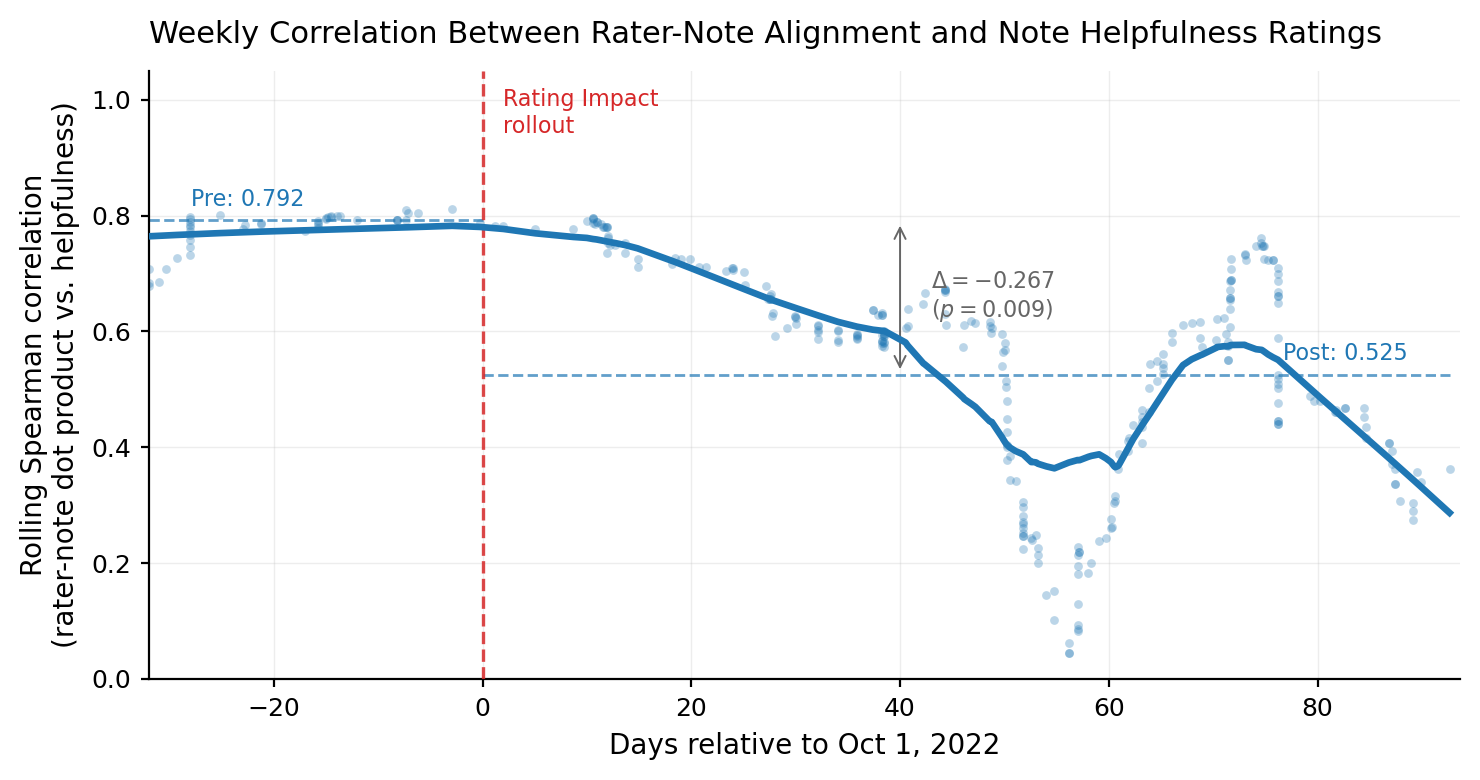

In [21]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib import dates as mdates
from src.visualization import (
    _C_BLUE, _C_EVENT, _C_ZERO,
    _FONT_LEGEND, _FONT_LABEL, _FONT_TITLE, _FONT_TICK, _FONT_ANNOT,
    _setup_ax, _finalize, apply_pnas_style,
)

# Use the actual rating timestamp (not the week bucket) so points spread over time.
df_plot_legacy = df_plot_legacy.copy()
df_plot_legacy["rating_dt"] = pd.to_datetime(df_plot_legacy["createdAtMillis"], unit="ms")
df_plot_legacy = df_plot_legacy.sort_values("rating_dt").reset_index(drop=True)

window = 50
min_periods = 20
rolling_spearman = []

for i in range(len(df_plot_legacy)):
    start_i = max(0, i - window)
    window_data = df_plot_legacy.iloc[start_i:i + 1]

    if len(window_data) < min_periods:
        rolling_spearman.append(np.nan)
    else:
        corr, _ = spearmanr(
            window_data["dot_product"],
            window_data["helpful_binary"],
        )
        rolling_spearman.append(corr)

df_plot_legacy["rolling_corr"] = rolling_spearman
df_plot_legacy["rolling_corr"] = df_plot_legacy["rolling_corr"].clip(-1, 1)

cutoff_dt = pd.to_datetime(cutoff)
# Continuous days (with fractional part) relative to cutoff, so x-positions vary within a week.
df_plot_legacy["days_rel"] = (
    (df_plot_legacy["rating_dt"] - cutoff_dt).dt.total_seconds() / 86400.0
)
valid = df_plot_legacy.dropna(subset=["rolling_corr", "days_rel"]).copy()

smoothed = lowess(
    valid["rolling_corr"].to_numpy(),
    valid["days_rel"].to_numpy(),
    frac=0.3,
    return_sorted=True,
)

pre_mean = corr_before
post_mean = corr_after
delta = observed_diff

apply_pnas_style()
fig, ax = plt.subplots(figsize=(7.5, 4.0))

ax.scatter(
    valid["days_rel"],
    valid["rolling_corr"],
    color=_C_BLUE,
    alpha=0.30,
    s=10,
    linewidths=0,
    zorder=2,
)
ax.plot(smoothed[:, 0], smoothed[:, 1], color=_C_BLUE, linewidth=2.4, zorder=4)
ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=3)
ax.axhline(0, color=_C_ZERO, linewidth=0.5, linestyle=":", zorder=1)

ax.hlines(pre_mean, valid["days_rel"].min(), 0, color=_C_BLUE, linewidth=1.0, linestyle="--", alpha=0.7)
ax.hlines(post_mean, 0, valid["days_rel"].max(), color=_C_BLUE, linewidth=1.0, linestyle="--", alpha=0.7)

ax.text(valid["days_rel"].min() + 4, pre_mean + 0.025, f"Pre: {pre_mean:.3f}", fontsize=_FONT_ANNOT, color=_C_BLUE)
ax.text(valid["days_rel"].max() - 4, post_mean + 0.025, f"Post: {post_mean:.3f}", fontsize=_FONT_ANNOT, color=_C_BLUE, ha="right")

arrow_x = min(40, valid["days_rel"].max() - 5)
ax.annotate(
    "",
    xy=(arrow_x, post_mean),
    xytext=(arrow_x, pre_mean),
    arrowprops=dict(arrowstyle="<->", color=_C_ZERO, linewidth=0.7),
)
ax.text(
    arrow_x + 3,
    (pre_mean + post_mean) / 2,
    f"$\\Delta = {delta:.3f}$\n$(p = {p_value:.3f})$",
    color=_C_ZERO,
    fontsize=_FONT_ANNOT,
    ha="left",
    va="center",
)

ax.text(2, 1.02, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top")
ax.set_xlim(valid["days_rel"].min(), valid["days_rel"].max() + 1)
ax.set_ylim(0, 1.05)

_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Days relative to Oct 1, 2022",
    ylabel="Rolling Spearman correlation\n(rater-note dot product vs. helpfulness)",
    title="Weekly Correlation Between Rater-Note Alignment and Note Helpfulness Ratings",
    save_path="final_code/figures-pnas/spearman-correlation-visualization.png",
)


In [100]:
before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

X_before = sm.add_constant(before['dot_product'])
y_before = before['helpful_binary']
model_before = sm.Logit(y_before, X_before).fit(disp=0)
coef_before = model_before.params['dot_product']

X_after = sm.add_constant(after['dot_product'])
y_after = after['helpful_binary']
model_after = sm.Logit(y_after, X_after).fit(disp=0)
coef_after = model_after.params['dot_product']
diff = coef_after - coef_before
print(coef_before)
print(coef_after)
print(diff)

all_data = df_plot_legacy
n_before = len(before)
observed_diff = coef_after - coef_before
perm_diffs = []

for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]

    try:
        m_before = sm.Logit(
            perm_before['helpful_binary'],
            sm.add_constant(perm_before['dot_product']),
        ).fit(disp=0)
        m_after = sm.Logit(
            perm_after['helpful_binary'],
            sm.add_constant(perm_after['dot_product']),
        ).fit(disp=0)
        perm_diffs.append(m_after.params['dot_product'] - m_before.params['dot_product'])
    except Exception:
        continue

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'Observed diff: {observed_diff:.4f}')
print(f'P-value: {p_value:.4f}')

apply_pnas_style()
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(
    perm_diffs,
    bins=40,
    color=_C_BLUE,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
    label="Permutation differences",
)
ax.axvline(
    observed_diff,
    color=_C_EVENT,
    linestyle="--",
    linewidth=1.2,
    label=f"Observed difference ({observed_diff:.3f})",
)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Difference in logistic regression coefficient",
    ylabel="Count",
    title="Permutation distribution for pre/post logistic coefficient difference",
    save_path="final_code/figures-pnas/permutation_logistic.png",
)

KeyError: 'week_dt'

In [57]:
weekly_coefs = []
start = '2022-08-01'
end = '2023-01-01'
df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]
df_plot_legacy = df_plot_legacy.set_index('week_dt')

for period, group in df_plot.groupby(pd.Grouper(freq='4W')):
    if group.empty:
        continue
    try:
        X = sm.add_constant(group['dot_product'])
        y = group['helpful_binary']
        model = sm.Logit(y, X).fit(disp=0)
        coef = model.params['dot_product']
        weekly_coefs.append((period, coef))
    except Exception as e:
        print(f'skipped {period}: {e}')
        continue

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [ ]:
# run RDD on the monthly logistic regression coefficient
monthly_coef_df['month'] = pd.to_datetime(monthly_coef_df['month'])
monthly_coef_df['month_num'] = monthly_coef_df['month'].map(pd.Timestamp.toordinal)

cutoff = pd.to_datetime("2022-10-01").toordinal()
monthly_coef_df['running'] = monthly_coef_df['month_num'] - cutoff
monthly_coef_df['post'] = (monthly_coef_df['running'] >= 0).astype(int)

model = smf.ols('coefficient ~ running + post + running:post', data=monthly_coef_df).fit(cov_type='HC1')
monthly_coef_df['fitted'] = model.fittedvalues

apply_pnas_style()
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.scatter(
    monthly_coef_df['month'],
    monthly_coef_df['coefficient'],
    color=_C_BLUE,
    alpha=0.55,
    s=22,
    linewidths=0,
    label="Observed",
    zorder=3,
)
ax.plot(
    monthly_coef_df['month'],
    monthly_coef_df['fitted'],
    color=_C_ZERO,
    linewidth=2.0,
    label="RDD fit",
    zorder=4,
)
ax.axvline(
    pd.to_datetime("2022-10-01"),
    linestyle="--",
    color=_C_EVENT,
    linewidth=1.2,
    alpha=0.85,
    label="Rating Impact rollout",
    zorder=5,
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Month",
    ylabel="Logit coefficient\n(dot product vs. helpfulness)",
    title="Regression discontinuity of alignment-helpfulness coefficient",
    save_path="final_code/figures-pnas/rdd_monthly_coef_2025.png",
)

# Annotations on Controversial Topics

In [22]:
history_df["noteId"]=history_df["noteId"].astype(int)

CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

notes_df_topic["controversial"] = np.select(
    [
        notes_df_topic['noteTopic'].isin(CONTROVERSIAL_TOPICS),
        notes_df_topic['noteTopic'].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

In [23]:
# Proportion of controversial vs. non-controversial LLAMA-labeled NEW notes
# from June 1, 2022 through June 1, 2023

START_DATE = "2022-06-01"
END_DATE = "2023-06-01"

CONTROVERSIAL_TOPICS = [
    "USPolitics", "UkraineConflict", "GazaConflict",
    "CrimeLegal", "HealthCovid", "EconomyFinance",
    "MessiRonaldo", "politics", "economy", "health"
]

NON_CONTROVERSIAL_TOPICS = [
    "SpaceAstronomy", "ClimateEnvironment", "EntertainmentMoviesTV",
    "WeatherDisasters", "TechCompanies", "SportsNFL", "SportsNBA",
    "FoodNutrition", "Education", "Scams",
    "ArtificialIntelligence", "science", "other"
]

# Merge LLAMA labels onto note metadata so we can use createdAtMillis
llm_notes = notes_df_topic.merge(
    notes_df_llms,
    left_on="noteId",
    right_on="NOTEID",
    how="inner"
).copy()

llm_notes["createdAtDate"] = pd.to_datetime(llm_notes["createdAtMillis"], unit="ms")

# NEW notes in date window
llm_notes_window = llm_notes[
    (llm_notes["createdAtDate"] >= pd.to_datetime(START_DATE)) &
    (llm_notes["createdAtDate"] < pd.to_datetime(END_DATE))
].copy()

llm_notes_window["LLAMA4_clean"] = (
    llm_notes_window["LLAMA4"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
)

llm_notes_window["controversy_label"] = np.select(
    [
        llm_notes_window["LLAMA4_clean"].isin(CONTROVERSIAL_TOPICS),
        llm_notes_window["LLAMA4_clean"].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

# Missingness check
n_total = len(llm_notes_window)
n_labeled = llm_notes_window["controversy_label"].notna().sum()
n_unlabeled = llm_notes_window["controversy_label"].isna().sum()

print(f"Total NEW notes in window: {n_total:,}")
print(f"Labeled controversial/non-controversial: {n_labeled:,} ({n_labeled / n_total:.2%})")
print(f"Unlabeled/other: {n_unlabeled:,} ({n_unlabeled / n_total:.2%})")

# Main proportion among labeled notes
controversy_counts = (
    llm_notes_window
    .dropna(subset=["controversy_label"])
    ["controversy_label"]
    .value_counts()
)

controversy_summary = pd.DataFrame({
    "count": controversy_counts,
    "proportion_among_labeled": controversy_counts / controversy_counts.sum(),
})

print(controversy_summary)

Total NEW notes in window: 4,488
Labeled controversial/non-controversial: 3,269 (72.84%)
Unlabeled/other: 1,219 (27.16%)
                   count  proportion_among_labeled
controversy_label                                 
Controversial       2557                  0.782196
Non-Controversial    712                  0.217804


In [24]:
llm_notes_window["LLAMA4_clean"].value_counts(dropna=False)

LLAMA4_clean
USPolitics                1763
COVID-19                   645
CrimeLegal                 419
Other                      254
UkraineConflict            201
Health                     195
TechCompanies              191
Scams                      152
EconomyFinance             148
ArtificialIntelligence     146
ClimateEnvironment          72
MoviesTV                    67
nan                         50
SpaceAstronomy              38
Education                   36
WeatherDisasters            33
GazaConflict                25
FoodNutrition               22
SportsNFL                   11
SportsNBA                   11
Sports                       3
SportsMLB                    2
SportsOther                  1
Environment                  1
MessiRonaldo                 1
SportsNASCAR                 1
Name: count, dtype: int64

In [25]:
all_expected = set(CONTROVERSIAL_TOPICS) | set(NON_CONTROVERSIAL_TOPICS)

unmatched = (
    llm_notes_window
    .loc[~llm_notes_window["LLAMA4_clean"].isin(all_expected), "LLAMA4_clean"]
    .value_counts(dropna=False)
)

print(unmatched)

LLAMA4_clean
COVID-19        645
Other           254
Health          195
MoviesTV         67
nan              50
Sports            3
SportsMLB         2
SportsOther       1
Environment       1
SportsNASCAR      1
Name: count, dtype: int64


In [26]:
def _wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        phat = np.where(n > 0, k / n, np.nan)
        denom = 1 + z**2 / n
        center = (phat + (z**2) / (2*n)) / denom
        margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
        lo = center - margin
        hi = center + margin
    return lo, hi

def _weighted_centered_rolling(values, weights, window):
    """Centered, weight-aware rolling mean (nan-safe)."""
    s = pd.Series(values, dtype=float)
    w = pd.Series(weights, dtype=float)
    def _avg(x):
        v = x.values
        ww = w.iloc[x.index].values
        mask = ~np.isnan(v) & ~np.isnan(ww) & (ww > 0)
        return np.average(v[mask], weights=ww[mask]) if mask.any() else np.nan
    return s.rolling(window=window, center=True, min_periods=1).apply(_avg, raw=False)

In [27]:
notes_df_topic.head()

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,week_dt,noteTopic,controversial
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,1,The House failed to pass a border protection l...,0.0,2024-04-22,USPolitics,Controversial
1,1883711635770196070,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1737946826294,1883619411774345444,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,1,0,...,0,0,0,0,1,This could be considered a threat https://...,0.0,2025-01-27,Scams,Non-Controversial
2,1537142913737428992,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655318404027,1377030478167937024,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,Forbes has a good rundown of the investigation...,0.0,2022-06-13,USPolitics,Controversial
3,1537147343715282945,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655319460217,1537080831751102467,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,LITTLE_HARM,EASY,0,0,...,0,0,0,0,1,Teslas purchased after 12/31/19 are not eligib...,0.0,2022-06-13,SpaceAstronomy,Non-Controversial
4,1537204430730211328,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655333070821,1537196168953974784,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,The Jan 6th riots were encouraged by the sitti...,0.0,2022-06-13,USPolitics,Controversial


In [28]:
# preprocess df
notes_df_topic_llm = notes_df_topic.merge(notes_df_llms, left_on='noteId', right_on='NOTEID')
notes_df_topic_llm['TOPIC'] = notes_df_topic_llm['TOPIC'].str.replace(' ', '', regex=False)
notes_df_topic_llm['LLAMA4'] = notes_df_topic_llm['LLAMA4'].str.replace(' ', '', regex=False)

In [29]:
def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    note_topic_col: str='noteTopic',
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # Merge & prepare
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))

    print(df.columns)
    df['note_creation_dt'] = pd.to_datetime(df['createdAtMillis_note'], unit='ms')

    df['topic_category'] = df[note_topic_col].apply(
        lambda x: 'Controversial' if x in CONTROVERSIAL_TOPICS
        else ('Non-Controversial' if x in NON_CONTROVERSIAL_TOPICS else 'Other')
    )

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby('tweetId')['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()
        unhelpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result


# --- usage -----------------------------------------------------------------
l_df, p_df = calculate_controversy_proportions_principled(history_df,
                                                    notes_df_topic_llm,
                                                    note_topic_col='LLAMA4',
                                                    time="W",
                                                    min_n=6, smooth_window=9)

Index(['noteId', 'noteAuthorParticipantId_status', 'createdAtMillis_status',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime',
       'noteAuthorParticipantId_note', 'createdAtMillis_note', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdate

In [30]:
p_df.head()

,week_dt,denominator_tweets_Controversial,helpful_Controversial,unhelpful_Controversial,prop_helpful_raw_Controversial,prop_unhelpful_raw_Controversial,prop_helpful_shrunk_Controversial,prop_unhelpful_shrunk_Controversial,prop_helpful_lo_Controversial,prop_helpful_hi_Controversial,...,prop_helpful_raw_Other,prop_unhelpful_raw_Other,prop_helpful_shrunk_Other,prop_unhelpful_shrunk_Other,prop_helpful_lo_Other,prop_helpful_hi_Other,prop_unhelpful_lo_Other,prop_unhelpful_hi_Other,prop_helpful_smooth_Other,prop_unhelpful_smooth_Other
0,2021-01-31,50,4,1,0.080000,0.02,0.088235,0.029412,3.154900e-02,0.188385,...,0.000000,0.04,0.019231,0.057692,0.000000e+00,0.133196,7.096050e-03,0.195445,0.042363,0.042791
1,2021-02-07,34,1,0,0.029412,0.00,0.042857,0.014286,5.210772e-03,0.149159,...,0.000000,0.00,0.027778,0.027778,0.000000e+00,0.184324,0.000000e+00,0.184324,0.043604,0.043992
2,2021-02-14,27,0,0,0.000000,0.00,0.017857,0.017857,6.938894e-18,0.124559,...,0.000000,0.00,0.038462,0.038462,0.000000e+00,0.242501,0.000000e+00,0.242501,0.038755,0.039060
3,2021-02-21,20,1,0,0.050000,0.00,0.071429,0.023810,8.881219e-03,0.236136,...,0.076923,0.00,0.107143,0.035714,1.371007e-02,0.333145,0.000000e+00,0.228102,0.045783,0.038403
4,2021-02-28,17,0,0,0.000000,0.00,0.027778,0.027778,0.000000e+00,0.184324,...,0.000000,0.00,0.045455,0.045455,-2.775558e-17,0.277540,-2.775558e-17,0.277540,0.035121,0.029917



Summary of mean helpfulness and 95% CI (Wilson):
  Controversial |  Pre | mean = 0.061, 95% CI = [0.042, 0.089]
  Controversial | Post | mean = 0.127, 95% CI = [0.106, 0.151]
Non-Controversial |  Pre | mean = 0.051, 95% CI = [0.020, 0.123]
Non-Controversial | Post | mean = 0.183, 95% CI = [0.138, 0.238]


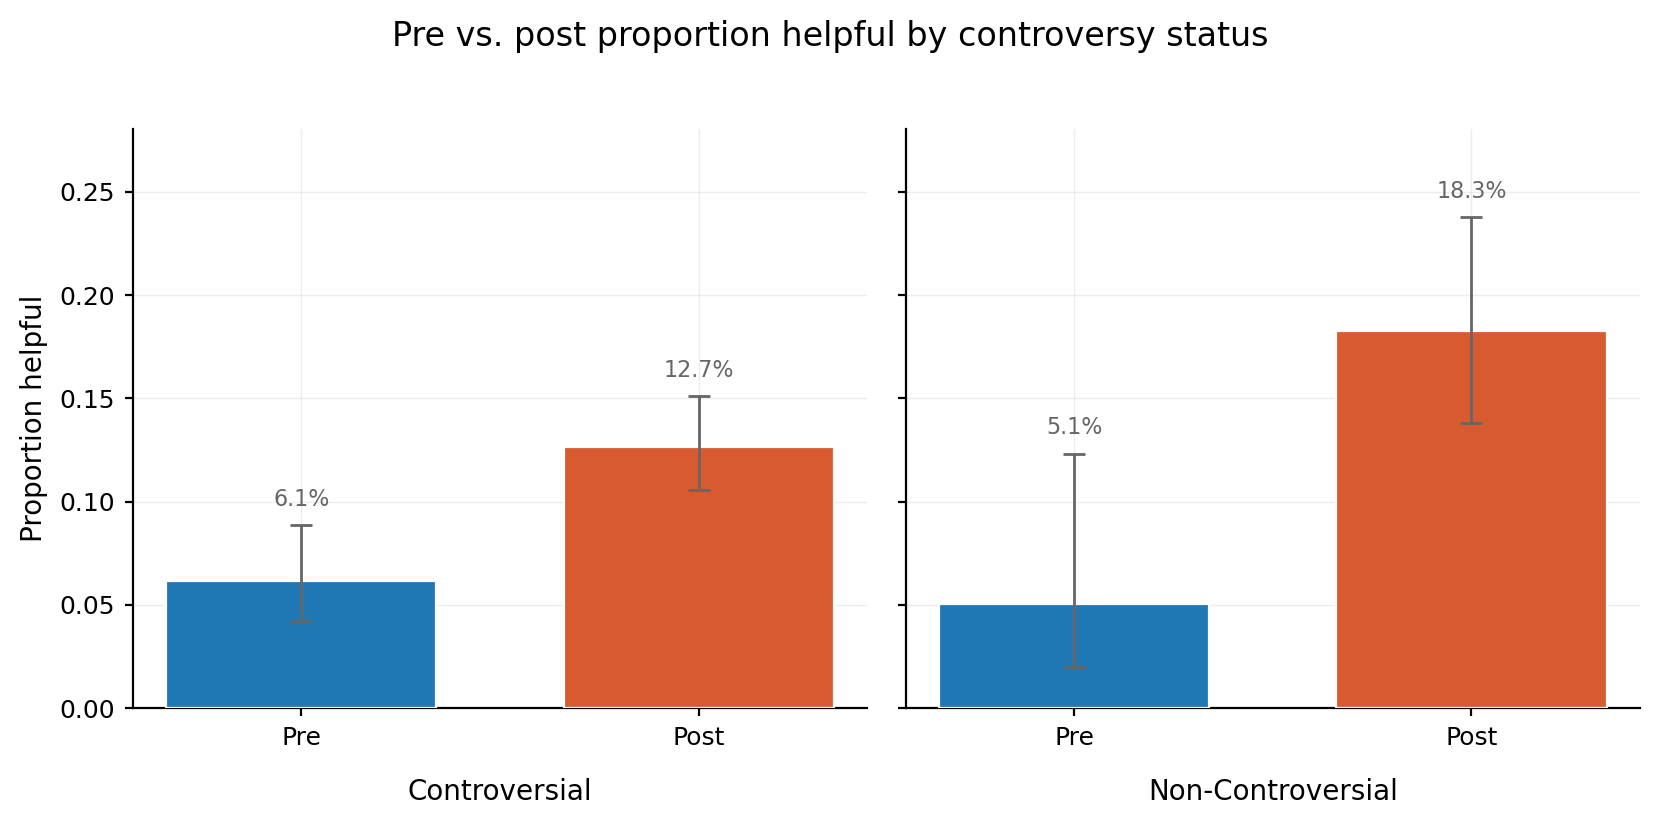

In [31]:
# --- utility: Wilson CI for aggregated counts ------------------------------
def wilson_ci_agg(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + (z**2) / (2*n)) / denom
    margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
    return center - margin, center + margin


def plot_pre_post_helpful_difference(
    df_weekly: pd.DataFrame,
    cutoff_date: str = "2022-10-01",
    categories=("Controversial", "Non-Controversial"),
    period_labels=("Pre", "Post"),
    colors=None,
    title="Pre vs. post proportion helpful by controversy status",
    path="final_code/figures-pnas/",
    suffix: str = "",
):
    if colors is None:
        colors = [_C_BLUE, _C_ORANGE]

    cutoff = pd.to_datetime(cutoff_date)
    df = df_weekly.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df.sort_values("week_dt")
    df["period"] = np.where(df["week_dt"] < cutoff, "Pre", "Post")

    rows = []
    for cat in categories:
        dcol = f"denominator_tweets_{cat}"
        hcol = f"helpful_{cat}"
        if dcol not in df.columns or hcol not in df.columns:
            raise KeyError(f"Expected columns '{dcol}' and '{hcol}' not found in dataframe.")

        for period in period_labels:
            g = df[df["period"] == period]
            n = np.nansum(g[dcol].values)
            k = np.nansum(g[hcol].values)
            p = (k / n) if n > 0 else np.nan
            lo, hi = wilson_ci_agg(k, n)
            rows.append({
                "category": cat,
                "period": period,
                "k_helpful": k,
                "n_den": n,
                "prop_helpful": p,
                "ci_lo": lo,
                "ci_hi": hi,
            })
    agg = pd.DataFrame(rows)

    print("\nSummary of mean helpfulness and 95% CI (Wilson):")
    for cat in categories:
        for period in period_labels:
            row = agg[(agg["category"] == cat) & (agg["period"] == period)]
            if not row.empty:
                p = row["prop_helpful"].values[0]
                lo = row["ci_lo"].values[0]
                hi = row["ci_hi"].values[0]
                print(f"{cat:>15} | {period:>4} | mean = {p:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]")

    apply_pnas_style()
    fig, axes = plt.subplots(1, len(categories), figsize=(4.2 * len(categories), 4.0), sharey=True)
    if len(categories) == 1:
        axes = [axes]

    ymax = agg["ci_hi"].max()
    if pd.isna(ymax):
        ymax = agg["prop_helpful"].max()
    ymax = min(1.0, ymax * 1.18)

    for ax, cat in zip(axes, categories):
        sub = agg[agg["category"] == cat].set_index("period").loc[list(period_labels)]
        x = np.arange(len(period_labels))
        y = sub["prop_helpful"].to_numpy(dtype=float)
        yerr = np.vstack([
            y - sub["ci_lo"].to_numpy(dtype=float),
            sub["ci_hi"].to_numpy(dtype=float) - y,
        ])

        ax.bar(
            x,
            y,
            width=0.68,
            color=colors[:len(period_labels)],
            edgecolor="white",
            linewidth=0.8,
            yerr=yerr,
            error_kw=dict(ecolor=_C_ZERO, lw=1.0, capsize=4, capthick=1.0),
            zorder=3,
        )

        for xi, prop, ci_hi in zip(x, y, sub["ci_hi"]):
            ax.text(
                xi,
                ci_hi + ymax * 0.025,
                f"{prop:.1%}",
                ha="center",
                va="bottom",
                fontsize=_FONT_ANNOT,
                color=_C_ZERO,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(period_labels, fontsize=_FONT_TICK)
        ax.set_xlabel(cat, fontsize=_FONT_LABEL, labelpad=10)
        ax.set_ylim(0, ymax)
        _setup_ax(ax)

    axes[0].set_ylabel("Proportion helpful", fontsize=_FONT_LABEL)
    _finalize(fig, axes, title=title)

    filename = f"{title.replace(' ', '_').replace(':', '')}{('_' + suffix) if suffix else ''}.png"
    fig.savefig(os.path.join(path, filename), dpi=300, bbox_inches="tight")
    plt.show()


plot_pre_post_helpful_difference(
    p_df[(p_df["week_dt"] < "2023-03-01") & (p_df["week_dt"] > "2022-06-01")],
    cutoff_date="2022-10-01",
    suffix="managed",
)

In [32]:
mask = (p_df["week_dt"] >= "2022-06-01") & (p_df["week_dt"] < "2023-06-01")

weekly_counts = pd.DataFrame({
    "week_dt": p_df.loc[mask, "week_dt"],
    "controversial":     p_df.loc[mask, "denominator_tweets_Controversial"].fillna(0).astype(int),
    "non_controversial": p_df.loc[mask, "denominator_tweets_Non-Controversial"].fillna(0).astype(int),
})
weekly_counts["total"] = weekly_counts["controversial"] + weekly_counts["non_controversial"]
weekly_counts["prop_controversial"] = np.where(
    weekly_counts["total"] > 0,
    weekly_counts["controversial"] / weekly_counts["total"],
    np.nan,
)
weekly_counts = weekly_counts.sort_values("week_dt").reset_index(drop=True)

print(weekly_counts.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

   week_dt  controversial  non_controversial  total  prop_controversial
2022-06-05             16                 21     37               0.432
2022-06-12             26                  4     30               0.867
2022-06-19             27                  7     34               0.794
2022-06-26             46                  7     53               0.868
2022-07-03             29                  2     31               0.935
2022-07-10             26                  8     34               0.765
2022-07-17             32                  3     35               0.914
2022-07-24             17                  4     21               0.810
2022-07-31             20                  0     20               1.000
2022-08-07             17                  2     19               0.895
2022-08-14             46                  0     46               1.000
2022-08-21             20                  3     23               0.870
2022-08-28             16                  3     19             

In [33]:
def _prepare_long_from_panel(panel_df, treated="Non-Controversial", control="Controversial",
                             min_n=30, use_jeffreys=True):
    """
    Returns long df with one row per (week, topic): week_dt, topic_type, prop, n_raw.
    prop uses Jeffreys smoothing for stability; n_raw is the raw denominator for weights.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    out = []
    for topic in (treated, control):
        k_raw = df[f"helpful_{topic}"].astype(float)
        n_raw = df[f"denominator_tweets_{topic}"].astype(float)

        # Smoothed proportion for stability, but keep RAW n for weights
        if use_jeffreys:
            k = k_raw + 0.5
            n = n_raw + 1.0
        else:
            k, n = k_raw, n_raw

        prop = np.where(n_raw > 0, k / n, np.nan)
        keep = (n_raw >= min_n) & np.isfinite(prop)

        out.append(pd.DataFrame({
            "week_dt": df["week_dt"],
            "topic_type": topic,
            "prop": pd.Series(prop).where(keep),
            "n_raw": n_raw.where(keep)
        }))

    long_df = pd.concat(out, ignore_index=True).dropna(subset=["prop", "n_raw"])
    return long_df


def _weekly_diff_series(long_df, treated, control, weight_mode="min"):
    """
    Balanced weekly difference series:
      diff_t = prop_treated_t - prop_control_t
      w_t    = min(n_treated_t, n_control_t) or sum(...), per weight_mode.
    """
    wide = long_df.pivot(index="week_dt", columns="topic_type", values=["prop", "n_raw"])
    props = wide["prop"]
    ns = wide["n_raw"]

    if treated not in props or control not in props:
        raise ValueError("After filtering, one of the topics is missing. Check names and min_n.")

    # Keep only weeks where both are observed
    diff = (props[treated] - props[control]).dropna()
    n_t = ns[treated].reindex(diff.index)
    n_c = ns[control].reindex(diff.index)

    if weight_mode == "sum":
        w = (n_t + n_c).astype(float)
    else:  # default "min"
        w = np.minimum(n_t, n_c).astype(float)

    w = w.clip(lower=1.0)

    series = pd.DataFrame({"diff": diff.astype(float), "w": w.astype(float)})
    series.index.name = "week_dt"
    return series


def _fit_window(y, w, is_post, hac_maxlags=4):
    """
    WLS diff-in-means (pre vs post) with HAC standard errors.
    y, w, is_post can be numpy arrays or pandas Series.
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    is_post = np.asarray(is_post, dtype=float)

    X = sm.add_constant(is_post)
    fit = sm.WLS(y, X, weights=w).fit(cov_type="HAC", cov_kwds={"maxlags": hac_maxlags})

    est = float(fit.params[1])
    se = float(fit.bse[1])
    p = float(fit.pvalues[1])
    z = 1.96
    ci = (est - z * se, est + z * se)
    return {"est": est, "se": se, "ci": ci, "p": p}


def did_windows_v2(panel_df,
                   change_date="2022-12-15",
                   treated="Non-Controversial",
                   control="Controversial",
                   pre_weeks=8,
                   short_post_weeks=8,
                   medium_post_weeks=(9, 26),
                   min_n=30,
                   use_jeffreys=True,
                   weight_mode="min",
                   hac_maxlags=4):
    """
    Short- and medium-run DiD on weekly helpfulness differences.
    Returns dict with 'short', 'medium', 'series', and 'meta'.
    """
    # Build balanced weekly diff series
    long_df = _prepare_long_from_panel(panel_df, treated, control, min_n, use_jeffreys)
    series = _weekly_diff_series(long_df, treated, control, weight_mode)
    series = series.sort_index()
    change_dt = pd.to_datetime(change_date)

    weeks = series.index

    # Pre window: last `pre_weeks` weeks strictly before the change
    pre_weeks_idx = weeks[weeks < change_dt]
    pre_weeks_idx = pre_weeks_idx[-pre_weeks:]  # if fewer exist, we take all available

    # Short post: from change_dt inclusive, take the next `short_post_weeks` observed weeks
    short_post_all = weeks[weeks >= change_dt]
    short_idx = short_post_all[:short_post_weeks]

    # Medium post: (lo, hi) weeks after change (inclusive)
    m_lo, m_hi = medium_post_weeks
    med_start = change_dt + pd.Timedelta(weeks=m_lo)
    med_end = change_dt + pd.Timedelta(weeks=m_hi)
    med_idx = weeks[(weeks >= med_start) & (weeks <= med_end)]

    def _run_window(idx_post):
        # aligned boolean masks (as Series) to avoid reindex warnings
        pre_mask = pd.Series(series.index.isin(pre_weeks_idx), index=series.index)
        post_mask = pd.Series(series.index.isin(idx_post), index=series.index)
        keep = pre_mask | post_mask

        y = series.loc[keep, "diff"]
        w = series.loc[keep, "w"]
        is_post = post_mask.loc[keep]

        # guard rails
        if y.size < 4 or is_post.sum() == 0 or (~is_post).sum() == 0:
            return {
                "est": np.nan, "se": np.nan, "ci": (np.nan, np.nan), "p": np.nan,
                "n_pre": int((~is_post).sum()), "n_post": int(is_post.sum()),
                "weeks_pre": list(pre_weeks_idx.astype(str)),
                "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
            }

        out = _fit_window(y.to_numpy(), w.to_numpy(), is_post.to_numpy(), hac_maxlags=hac_maxlags)
        out.update({
            "n_pre": int((~is_post).sum()),
            "n_post": int(is_post.sum()),
            "weeks_pre": list(pre_weeks_idx.astype(str)),
            "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
        })
        return out

    short_res = _run_window(short_idx)
    medium_res = _run_window(med_idx)

    return {
        "short": short_res,
        "medium": medium_res,
        "series": series.reset_index(),  # columns: week_dt, diff, w
        "meta": {
            "change_date": str(pd.to_datetime(change_date).date()),
            "pre_weeks": pre_weeks,
            "short_post_weeks": short_post_weeks,
            "medium_post_weeks": medium_post_weeks,
            "min_n": min_n,
            "weight_mode": weight_mode,
            "use_jeffreys": use_jeffreys,
            "hac_maxlags": hac_maxlags,
            "treated": treated,
            "control": control,
        },
    }


In [34]:
res = did_windows_v2(
    p_df,
    change_date="2022-10-01",
    treated="Non-Controversial",
    control="Controversial",
    pre_weeks=12,                # short-run baseline window
    short_post_weeks=12,          # short-run post
    medium_post_weeks=(13, 26),   # medium-run post
    min_n=5,                    # require both groups to have ≥10 tweets that week
    use_jeffreys=True,
    weight_mode="min",           # or "sum"
    hac_maxlags=4
)

print(res["short"])    # dict: est, se, ci, p, n_pre, n_post, weeks_pre, weeks_post
print(res["medium"])   # same for the medium window
res["series"].head() 

{'est': -0.008363752214092034, 'se': 0.0368144907663, 'ci': (-0.08052015411604004, 0.06379264968785596), 'p': 0.8202787900133578, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2021-11-14', '2022-01-09', '2022-03-06', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-19', '2022-06-26', '2022-07-10', '2022-09-11'], 'weeks_post': ['2022-10-02', '2022-10-09', '2022-10-16', '2022-10-30', '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27', '2022-12-04', '2022-12-11', '2022-12-18', '2023-01-01']}
{'est': 0.0698368731993066, 'se': 0.05093110183549574, 'ci': (-0.029988086398265043, 0.16966183279687824), 'p': 0.17031172262243033, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2021-11-14', '2022-01-09', '2022-03-06', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-19', '2022-06-26', '2022-07-10', '2022-09-11'], 'weeks_post': ['2023-01-01', '2023-01-08', '2023-01-22', '2023-01-29', '2023-02-05', '2023-02-12', '2023-02-19', '2023-02-26', '2023-

,week_dt,diff,w
0,2021-02-07,0.028571,6.0
1,2021-02-21,0.035714,13.0
2,2021-05-02,0.061224,6.0
3,2021-08-29,0.131944,7.0
4,2021-09-26,0.067708,5.0


In [35]:
notes_df_topic.head()

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,week_dt,noteTopic,controversial
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,1,The House failed to pass a border protection l...,0.0,2024-04-22,USPolitics,Controversial
1,1883711635770196070,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1737946826294,1883619411774345444,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,1,0,...,0,0,0,0,1,This could be considered a threat https://...,0.0,2025-01-27,Scams,Non-Controversial
2,1537142913737428992,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655318404027,1377030478167937024,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,Forbes has a good rundown of the investigation...,0.0,2022-06-13,USPolitics,Controversial
3,1537147343715282945,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655319460217,1537080831751102467,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,LITTLE_HARM,EASY,0,0,...,0,0,0,0,1,Teslas purchased after 12/31/19 are not eligib...,0.0,2022-06-13,SpaceAstronomy,Non-Controversial
4,1537204430730211328,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655333070821,1537196168953974784,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,The Jan 6th riots were encouraged by the sitti...,0.0,2022-06-13,USPolitics,Controversial


In [36]:
# check controversial raw counts

def get_controversial_counts(notes_df_topic, cutoff_date="2022-10-01", window_weeks=12):
    """
    Returns 4 proportions:
      - pre_prop_controversial, pre_prop_non_controversial,
      - post_prop_controversial, post_prop_non_controversial

    Denominator in each period = unique tweets with any note in that period.
    Numerators = unique tweets that have at least one note labeled Controversial / Non-Controversial.
    (A tweet can count in both numerators if it has notes in both categories in the same period.)
    """
    df = notes_df_topic.copy()

    cutoff = pd.to_datetime(cutoff_date)

    # Put each note into a weekly bucket (week ending Sunday). Change freq if you want.
    df["week_dt"] = pd.to_datetime(df["createdAtMillis"], unit="ms").dt.to_period("W").dt.end_time

    # Define pre/post windows as weeks (like your DiD setup)
    pre_start = (cutoff - pd.Timedelta(weeks=window_weeks)).to_period("W").end_time
    pre_end   = (cutoff - pd.Timedelta(days=1)).to_period("W").end_time  # strictly before cutoff week
    post_start = cutoff.to_period("W").end_time
    post_end   = (cutoff + pd.Timedelta(weeks=window_weeks) - pd.Timedelta(days=1)).to_period("W").end_time

    pre = df[(df["week_dt"] >= pre_start) & (df["week_dt"] <= pre_end)]
    post = df[(df["week_dt"] >= post_start) & (df["week_dt"] <= post_end)]

    def _props(d):
        total = d["tweetId"].nunique()
        if total == 0:
            return {"controversial": float("nan"), "non_controversial": float("nan")}

        n_cont = d.loc[d["controversial"].eq("Controversial"), "tweetId"].nunique()
        n_non  = d.loc[d["controversial"].eq("Non-Controversial"), "tweetId"].nunique()

        return {
            "controversial": n_cont / total,
            "non_controversial": n_non / total,
        }

    pre_p = _props(pre)
    post_p = _props(post)

    return {
        "pre_prop_controversial": pre_p["controversial"],
        "pre_prop_non_controversial": pre_p["non_controversial"],
        "post_prop_controversial": post_p["controversial"],
        "post_prop_non_controversial": post_p["non_controversial"],
    }


In [37]:
get_controversial_counts(notes_df_topic)

{'pre_prop_controversial': 0.8706140350877193,
 'pre_prop_non_controversial': 0.12938596491228072,
 'post_prop_controversial': 0.8360849056603774,
 'post_prop_non_controversial': 0.16391509433962265}

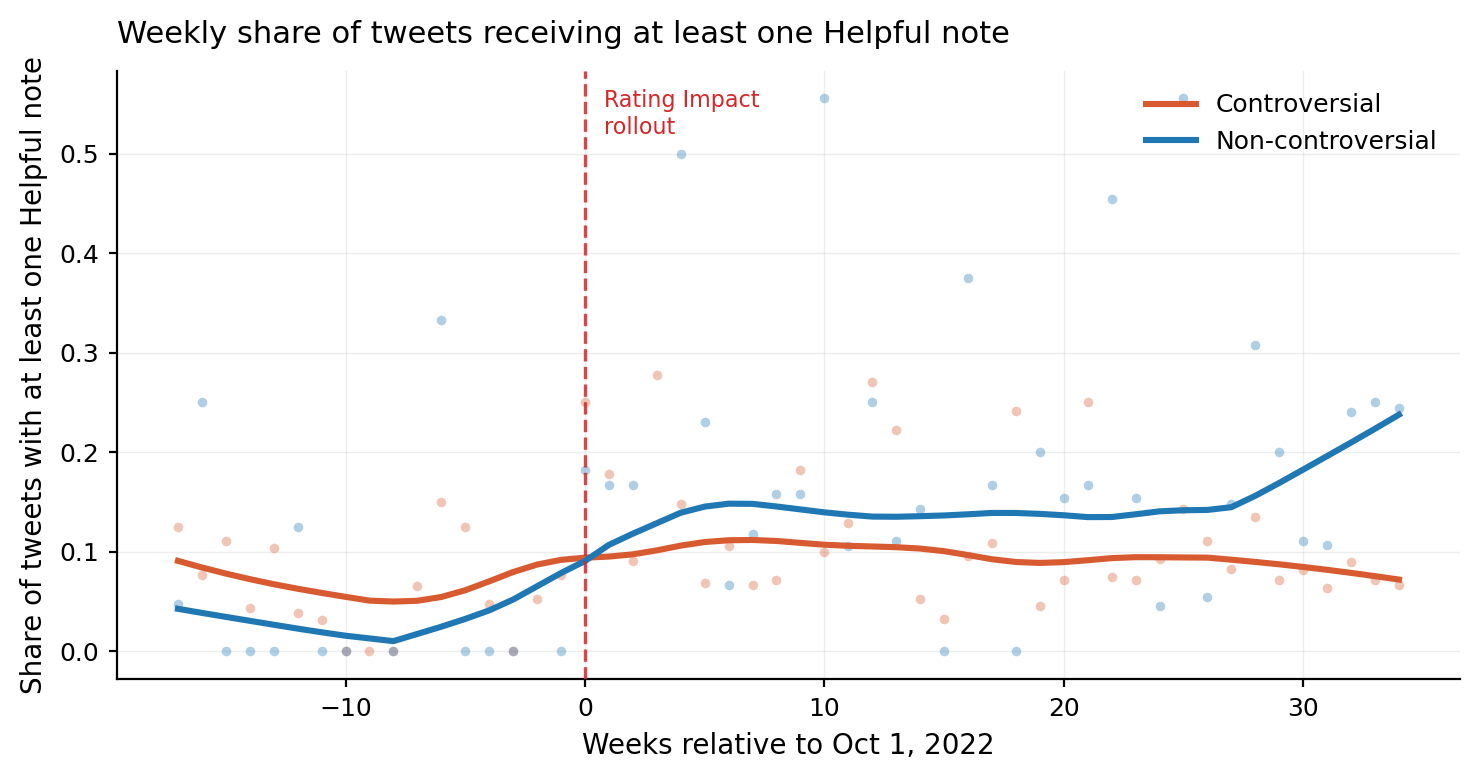

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess


def plot_weekly_helpful_attainment_by_controversy(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    categories=("Controversial", "Non-Controversial"),
    labels=("Controversial", "Non-controversial"),
    colors=None,
    frac_lowess=0.35,
    n_boot=500,
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy.png",
    title="Weekly share of tweets receiving at least one Helpful note",
):
    if colors is None:
        colors = [_C_ORANGE, _C_BLUE]

    cutoff = pd.to_datetime(cutoff_date)
    df = p_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df[
        (df["week_dt"] >= pd.to_datetime(date_range[0])) &
        (df["week_dt"] <= pd.to_datetime(date_range[1]))
    ].sort_values("week_dt")
    df["week_rel"] = ((df["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    rng = np.random.default_rng(0)
    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for cat, label, color in zip(categories, labels, colors):
        n_col = f"denominator_tweets_{cat}"
        k_col = f"helpful_{cat}"
        prop_col = f"prop_helpful_attainment_{cat}"
        df[prop_col] = np.where(df[n_col].fillna(0) > 0, df[k_col].fillna(0) / df[n_col], np.nan)

        sub = df[["week_rel", prop_col]].dropna()
        x = sub["week_rel"].to_numpy(dtype=float)
        y = sub[prop_col].to_numpy(dtype=float)

        ax.scatter(x, y, color=color, alpha=0.35, s=12, linewidths=0, zorder=2)
        sm = _lowess(y, x, frac=frac_lowess, return_sorted=True)
        xs, ys = sm[:, 0], sm[:, 1]
        ax.plot(xs, ys, color=color, linewidth=2.2, label=label, zorder=4)

        boots = np.empty((n_boot, xs.size))
        for b in range(n_boot):
            idx = rng.integers(0, len(x), len(x))
            bsm = _lowess(y[idx], x[idx], frac=frac_lowess, return_sorted=True)
            boots[b] = np.interp(xs, bsm[:, 0], bsm[:, 1])

        # ax.fill_between(
        #     xs,
        #     np.percentile(boots, 2.5, axis=0),
        #     np.percentile(boots, 97.5, axis=0),
        #     color=color,
        #     alpha=0.15,
        #     linewidth=0,
        #     zorder=2,
        # )

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(0.8, 0.97, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top", ha="left", transform=ax.get_xaxis_transform())
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks relative to Oct 1, 2022",
        ylabel="Share of tweets with at least one Helpful note",
        title=title,
        save_path=save_path,
    )


plot_weekly_helpful_attainment_by_controversy(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy_raw_no_CI.png",
)

In [ ]:
def plot_weekly_helpful_attainment_by_controversy(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    categories=("Controversial", "Non-Controversial"),
    labels=("Controversial", "Non-controversial"),
    colors=None,
    frac_lowess=0.35,
    ci_mode="wilson",     # "wilson" | "binomial_boot" | "none"
    n_boot=2000,          # only used when ci_mode="binomial_boot"
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy_test.png",
    title="Weekly share of tweets receiving at least one Helpful note",
):
    if colors is None:
        colors = [_C_ORANGE, _C_BLUE]

    cutoff = pd.to_datetime(cutoff_date)
    df = p_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df[
        (df["week_dt"] >= pd.to_datetime(date_range[0])) &
        (df["week_dt"] <= pd.to_datetime(date_range[1]))
    ].sort_values("week_dt")
    df["week_rel"] = ((df["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    rng = np.random.default_rng(0)
    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for cat, label, color in zip(categories, labels, colors):
        n_col = f"denominator_tweets_{cat}"
        k_col = f"helpful_{cat}"
        prop_col = f"prop_helpful_attainment_{cat}"
        df[prop_col] = np.where(df[n_col].fillna(0) > 0,
                                df[k_col].fillna(0) / df[n_col], np.nan)

        sub = df[["week_rel", prop_col, n_col, k_col]].dropna(subset=["week_rel", prop_col])
        x = sub["week_rel"].to_numpy(dtype=float)
        y = sub[prop_col].to_numpy(dtype=float)
        n = sub[n_col].to_numpy(dtype=float)
        k = sub[k_col].to_numpy(dtype=float)

        ax.scatter(x, y, color=color, alpha=0.35, s=12, linewidths=0, zorder=2)
        sm = _lowess(y, x, frac=frac_lowess, return_sorted=True)
        xs, ys = sm[:, 0], sm[:, 1]
        ax.plot(xs, ys, color=color, linewidth=2.2, label=label, zorder=4)

        # --- per-week CI band ---
        if ci_mode == "wilson":
            lo_col = f"prop_helpful_lo_{cat}"
            hi_col = f"prop_helpful_hi_{cat}"
            if lo_col in df.columns and hi_col in df.columns:
                ci = df[["week_rel", lo_col, hi_col]].dropna().sort_values("week_rel")
                ax.fill_between(ci["week_rel"], ci[lo_col], ci[hi_col],
                                color=color, alpha=0.18, linewidth=0, zorder=2)
                # also bar at each observed week (optional): ax.vlines(...)

        elif ci_mode == "binomial_boot":
            order = np.argsort(x)
            x_s = x[order]; n_s = n[order]; p_s = y[order]
            # draw B binomial samples per week
            mask = n_s > 0
            B = n_boot
            samples = np.empty((B, x_s.size))
            samples[:] = np.nan
            if mask.any():
                draws = rng.binomial(
                    n_s[mask].astype(int).reshape(1, -1).repeat(B, axis=0),
                    p_s[mask].reshape(1, -1).repeat(B, axis=0),
                ) / n_s[mask]
                samples[:, mask] = draws
            lo = np.nanpercentile(samples, 2.5, axis=0)
            hi = np.nanpercentile(samples, 97.5, axis=0)
            ax.fill_between(x_s, lo, hi, color=color, alpha=0.18,
                            linewidth=0, zorder=2)

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(0.8, 0.97, "Rating Impact\nrollout", color=_C_EVENT,
            fontsize=_FONT_ANNOT, va="top", ha="left",
            transform=ax.get_xaxis_transform())
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig, ax,
        xlabel="Weeks relative to Oct 1, 2022",
        ylabel="Share of tweets with at least one Helpful note",
        title=title,
        save_path=save_path,
    )

    

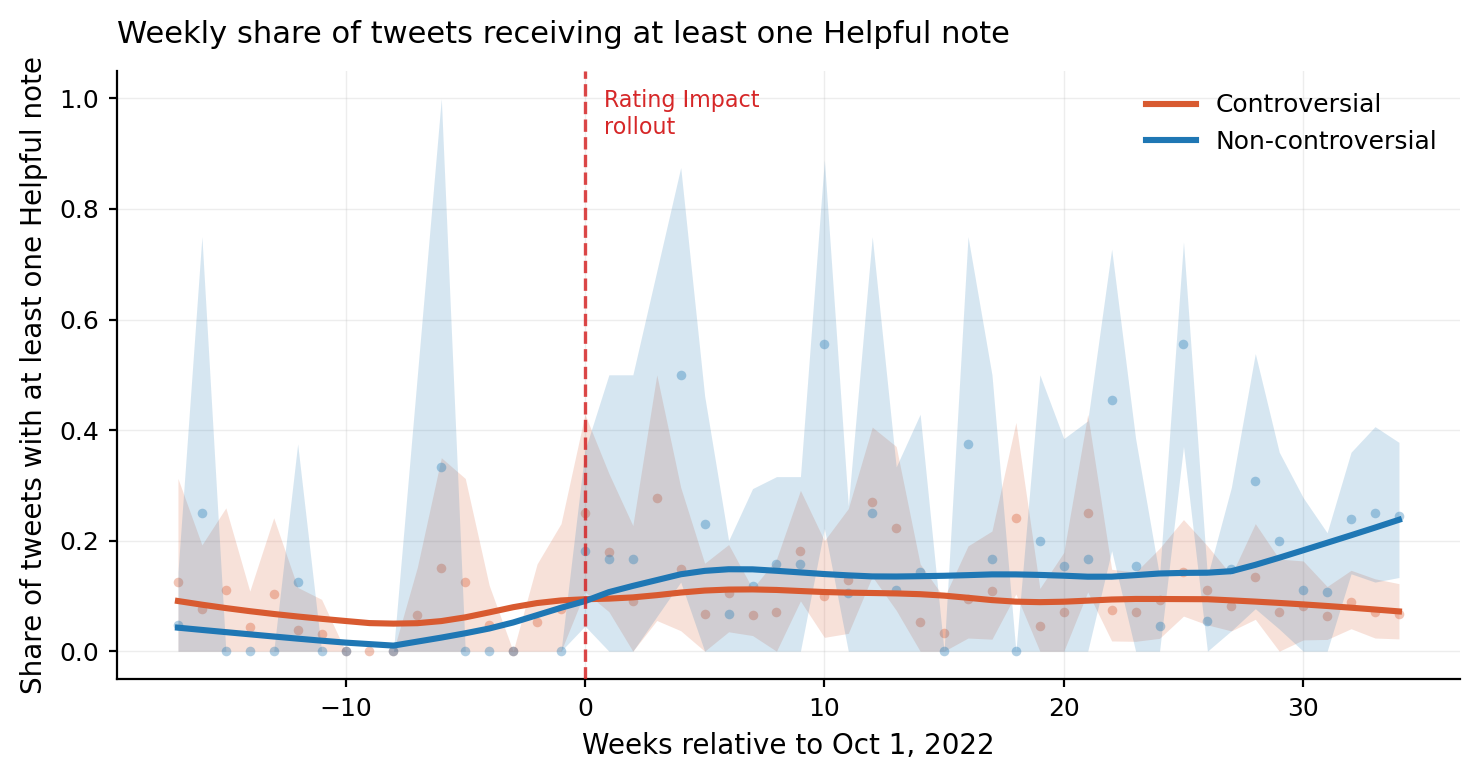

In [44]:
plot_weekly_helpful_attainment_by_controversy(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    ci_mode="binomial_boot",            # or "binomial_boot"
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy_test.png",
)

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess


def plot_weekly_helpful_attainment_by_controversy_shrunk(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    prop_col_tmpl="prop_helpful_shrunk_{}",
    categories=("Controversial", "Non-Controversial"),
    labels=("Controversial", "Non-controversial"),
    colors=None,
    did_result=None,
    frac_lowess=0.35,
    n_boot=500,
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy_shrunk.png",
    title="Weekly share of tweets receiving at least one Helpful note",
):
    if colors is None:
        colors = [_C_ORANGE, _C_BLUE]

    cutoff = pd.to_datetime(cutoff_date)
    df = p_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df[
        (df["week_dt"] >= pd.to_datetime(date_range[0])) &
        (df["week_dt"] <= pd.to_datetime(date_range[1]))
    ].sort_values("week_dt")
    df["week_rel"] = ((df["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    rng = np.random.default_rng(0)
    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for cat, label, color in zip(categories, labels, colors):
        prop_col = prop_col_tmpl.format(cat)
        sub = df[["week_rel", prop_col]].dropna()
        x = sub["week_rel"].to_numpy(dtype=float)
        y = sub[prop_col].to_numpy(dtype=float)

        ax.scatter(x, y, color=color, alpha=0.35, s=12, linewidths=0, zorder=2)
        sm = _lowess(y, x, frac=frac_lowess, return_sorted=True)
        xs, ys = sm[:, 0], sm[:, 1]
        ax.plot(xs, ys, color=color, linewidth=2.2, label=label, zorder=4)

        boots = np.empty((n_boot, xs.size))
        for b in range(n_boot):
            idx = rng.integers(0, len(x), len(x))
            bsm = _lowess(y[idx], x[idx], frac=frac_lowess, return_sorted=True)
            boots[b] = np.interp(xs, bsm[:, 0], bsm[:, 1])

        ax.fill_between(
            xs,
            np.percentile(boots, 2.5, axis=0),
            np.percentile(boots, 97.5, axis=0),
            color=color,
            alpha=0.15,
            linewidth=0,
            zorder=2,
        )

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(0.8, 0.97, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top", ha="left", transform=ax.get_xaxis_transform())

    if did_result is not None:
        s = did_result["short"]
        est_pp = s["est"] * 100
        lo_pp = s["ci"][0] * 100
        hi_pp = s["ci"][1] * 100
        annot = f"DiD weeks 0-12: {est_pp:+.1f} pp [{lo_pp:.1f}, {hi_pp:.1f}]"
        ax.text(
            0.98,
            0.04,
            annot,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=_FONT_ANNOT,
            color=_C_ZERO,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=_C_LIGHT, lw=0.7, alpha=0.9),
        )

    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks relative to Oct 1, 2022",
        ylabel="Share of tweets with at least one Helpful note",
        title=title,
        save_path=save_path,
    )


plot_weekly_helpful_attainment_by_controversy_shrunk(
    p_df,
    cutoff_date="2022-10-01",
    date_range=("2022-06-01", "2023-06-01"),
    did_result=res,
    save_path="final_code/figures-pnas/weekly_helpful_attainment_by_controversy_shrunk.png",
)

# Predictive Accuracy

In [77]:
ratings_filtered = ratings_df[ratings_df['raterParticipantId'].isin(legacy_users)]

In [89]:
def merge_factors_safe(ratings_df, note_df, rater_df, in_sample=False):
    """
    Attach most recent rater and note factors to each rating row, keeping factor dates,
    computing helpful_binary, vote_label, and pre_estimate, while preserving all rows.
    Setting `in_sample = False` gives us the factors for one-week ahead estimates for matrix factorization.
    """
    # Work on copies
    ratings = ratings_df.copy()
    note = note_df.copy()
    rater = rater_df.copy()

    # Normalize IDs to string
    ratings['noteId'] = ratings['noteId'].astype(str)
    ratings['raterParticipantId'] = ratings['raterParticipantId'].astype(str)
    note['noteId'] = note['noteId'].astype(str)
    rater['raterParticipantId'] = rater['raterParticipantId'].astype(str)

    # Convert timestamps
    ratings['createdAtDate'] = pd.to_datetime(ratings['createdAtMillis'], unit='ms')
    
    
    ratings['week_dt'] = ratings['createdAtDate'].dt.to_period('W').dt.start_time
    note['week_dt'] = pd.to_datetime(note['week_dt']).dt.normalize()
    rater['week_dt'] = pd.to_datetime(rater['week_dt']).dt.normalize()

    # Sort frames for merge_asof
    ratings_note_sorted = ratings.sort_values(['week_dt', 'noteId']).reset_index().rename(columns={'index':'__orig_index'})
    ratings_rater_sorted = ratings.sort_values(['week_dt', 'raterParticipantId']).reset_index().rename(columns={'index':'__orig_index'})
    note_sorted = note.sort_values(['week_dt', 'noteId']).reset_index(drop=True)
    rater_sorted = rater.sort_values(['week_dt', 'raterParticipantId']).reset_index(drop=True)

    # Merge note factors (most recent at or before rating week)
    note_merge = pd.merge_asof(
        ratings_note_sorted,
        note_sorted[['noteId','week_dt','noteFactor1','noteIntercept']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=in_sample
    )
    # Keep factor date
    note_merge = note_merge.rename(columns={'week_dt':'note_factor_week'})

    # Merge rater factors
    rater_merge = pd.merge_asof(
        ratings_rater_sorted,
        rater_sorted[['raterParticipantId','week_dt','raterFactor1','raterIntercept']],
        by='raterParticipantId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=in_sample
    )
    rater_merge = rater_merge.rename(columns={'week_dt':'rater_factor_week'})

    # Combine back to original ratings
    combined = ratings.copy().reset_index().rename(columns={'index':'__orig_index'}).set_index('__orig_index')
    combined = combined.join(
        note_merge.set_index('__orig_index')[['note_factor_week','noteFactor1','noteIntercept']],
        how='left'
    )
    combined = combined.join(
        rater_merge.set_index('__orig_index')[['rater_factor_week','raterFactor1','raterIntercept']],
        how='left'
    )

    # Convert helpfulness labels
    combined['helpful_binary'] = np.where(
        combined['helpfulnessLevel']=='HELPFUL', 1,
        np.where(combined['helpfulnessLevel']=='NOT_HELPFUL',0,np.nan)
    )

    # Drop rows missing required factors or label
    combined = combined.dropna(subset=['noteFactor1','raterFactor1','helpful_binary']).copy()

    # Compute vote_label
    combined['vote_label'] = combined['helpful_binary'].map({1:'Helpful',0:'Not Helpful'})

    # Restore original index
    combined = combined.reset_index(drop=True)
    return combined

In [90]:
def compute_pre_estimate(df):
    df = df.copy()
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    return df

def compute_global_unweighted_means(df):
    df = compute_pre_estimate(df.copy())
    result_df = (
        df.groupby('week_dt', sort=True)
          .apply(lambda x: np.mean(x['helpful_binary'] - x['pre_estimate_mf']))
          .reset_index(name='mu')
    )
    return result_df


def compute_matrix_factorization_estimates(df, in_sample=True):
    '''
    Note: if in_sample = False, then use the most recent *previous* estimate for the global mean
    '''
    df = df.copy()
    mu_df = compute_global_unweighted_means(df)
    
    # Compute MF pre-estimate
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    if in_sample:
        # use same-week mu
        df = df.merge(mu_df, on='week_dt', how='left')
    else:
        # use previous week's mu
        mu_df = mu_df.sort_values('week_dt').copy()
        mu_df['mu'] = mu_df['mu'].shift(1)   # shift one row down
        df = df.merge(mu_df, on='week_dt', how='left')

        # handle the first week (no previous mu available)
        df['mu'] = df['mu'].fillna(mu_df['mu'].mean())

    # Compute MF estimates by adding mu back
    df['estimate_mf'] = df['mu'] + df['pre_estimate_mf']

    return df

In [91]:
df_in_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=True)
df_out_of_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=False)
display(df_in_sample.shape, df_out_of_sample.shape)

(14177, 14)

(2229, 14)

In [92]:
# these are the two relevant dataframes for matrix factorization in-sample and one week ahead estimates
df_in_sample_mf = compute_matrix_factorization_estimates(df_in_sample, in_sample=True)
df_out_of_sample_mf = compute_matrix_factorization_estimates(df_out_of_sample, in_sample=False)

/tmp/ipykernel_3838238/3233219998.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3838238/3233219998.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [93]:
df_in_sample_mf['squared_residual_in_sample'] = (df_in_sample_mf['estimate_mf'] - df_in_sample_mf['helpful_binary'])**2
df_out_of_sample_mf['squared_residual_oos'] = (df_out_of_sample_mf['estimate_mf'] - df_out_of_sample_mf['helpful_binary'])**2

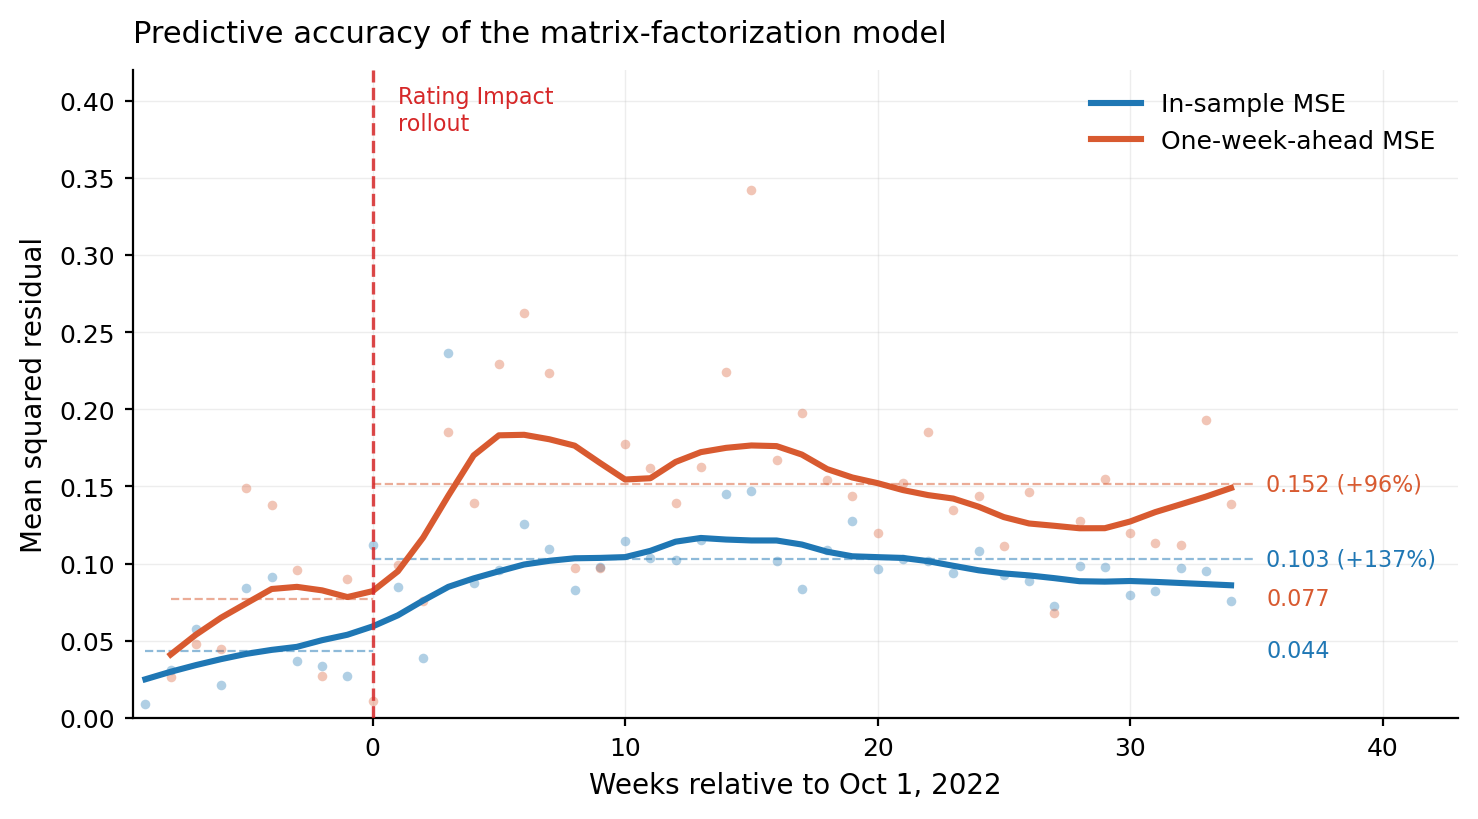

In [94]:
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess
from src.visualization import (
    _C_BLUE, _C_ORANGE, _C_EVENT, _C_ZERO,
    _FONT_LEGEND, _FONT_LABEL, _FONT_TITLE, _FONT_TICK, _FONT_ANNOT,
    _setup_ax, _finalize, apply_pnas_style,
)


def plot_mf_residuals_by_week_pnas(
    df_in_sample_mf,
    df_out_of_sample_mf,
    cutoff_date="2022-10-01",
    frac_lowess=0.25,
    save_path="final_code/figures-pnas/mf_residuals_by_week_2025.png",
    title="Predictive accuracy of the matrix-factorization model",
):
    cutoff = pd.to_datetime(cutoff_date)

    in_week = (
        df_in_sample_mf
        .groupby("week_dt")["squared_residual_in_sample"]
        .agg(["mean", "std", "count"])
        .sort_index()
    )
    in_week.index = pd.to_datetime(in_week.index)
    in_week["week_rel"] = ((in_week.index - cutoff).days / 7).round().astype(int)

    oos_week = (
        df_out_of_sample_mf
        .groupby("week_dt")["squared_residual_oos"]
        .agg(["mean", "std", "count"])
        .sort_index()
    )
    oos_week.index = pd.to_datetime(oos_week.index)
    oos_week["week_rel"] = ((oos_week.index - cutoff).days / 7).round().astype(int)

    apply_pnas_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.2))

    series_specs = [
        (in_week, "In-sample MSE", _C_BLUE),
        (oos_week, "One-week-ahead MSE", _C_ORANGE),
    ]

    for week_df, label, color in series_specs:
        x = week_df["week_rel"].to_numpy(dtype=float)
        y = week_df["mean"].to_numpy(dtype=float)

        ax.scatter(x, y, color=color, alpha=0.35, s=12, linewidths=0, zorder=2)
        sm = _lowess(y, x, frac=frac_lowess, return_sorted=True)
        ax.plot(sm[:, 0], sm[:, 1], color=color, linewidth=2.2, label=label, zorder=4)

        pre = week_df[week_df["week_rel"] < 0]["mean"]
        post = week_df[week_df["week_rel"] >= 0]["mean"]
        pre_mean = pre.mean()
        post_mean = post.mean()
        pct_change = ((post_mean / pre_mean) - 1) * 100

        ax.hlines(pre_mean, xmin=x.min(), xmax=0, color=color, linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)
        ax.hlines(post_mean, xmin=0, xmax=x.max() + 1, color=color, linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)
        ax.text(x.max() + 1.4, post_mean, f"{post_mean:.3f} ({pct_change:+.0f}%)", color=color, fontsize=_FONT_ANNOT, va="center", ha="left")
        ax.text(x.max() + 1.4, pre_mean, f"{pre_mean:.3f}", color=color, fontsize=_FONT_ANNOT, va="center", ha="left")

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(1, 0.41, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top", ha="left")

    x_min = min(in_week["week_rel"].min(), oos_week["week_rel"].min())
    x_max = max(in_week["week_rel"].max(), oos_week["week_rel"].max())
    ax.set_xlim(x_min - 0.5, x_max + 9)
    ax.set_ylim(0, 0.42)
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks relative to Oct 1, 2022",
        ylabel="Mean squared residual",
        title=title,
        save_path=save_path,
    )


plot_mf_residuals_by_week_pnas(
    df_in_sample_mf,
    df_out_of_sample_mf,
    cutoff_date="2022-10-01",
    save_path="final_code/figures-pnas/mf_residuals_by_week_2025.png",
)

In [95]:
def avg_mse_pre_post(df, cutoff, months, date_col="week_dt", mse_col="mse"):
    cutoff = pd.to_datetime(cutoff)
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    pre  = d[(d[date_col] >= cutoff - pd.DateOffset(months=months)) & (d[date_col] < cutoff)][mse_col].dropna()
    post = d[(d[date_col] >= cutoff) & (d[date_col] < cutoff + pd.DateOffset(months=months))][mse_col].dropna()

    pre_mean, post_mean = pre.mean(), post.mean()
    pre_se  = pre.std(ddof=1) / np.sqrt(len(pre))
    post_se = post.std(ddof=1) / np.sqrt(len(post))

    pre_ci  = (pre_mean  - 1.96*pre_se,  pre_mean  + 1.96*pre_se)
    post_ci = (post_mean - 1.96*post_se, post_mean + 1.96*post_se)

    return pre_mean, pre_ci, post_mean, post_ci


In [96]:
pre_mean, pre_ci, post_mean, post_ci = avg_mse_pre_post(
    df_in_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_in_sample"
)


In [97]:
print(pre_mean, pre_ci, post_mean, post_ci)

0.048752172599057696 (np.float64(0.03266704287024469), np.float64(0.0648373023278707)) 0.10568706896191987 (np.float64(0.10052730874661477), np.float64(0.11084682917722498))


In [98]:
pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos = avg_mse_pre_post(
    df_out_of_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_oos"
)


In [99]:
print(pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos)

0.09270713817283788 (np.float64(0.060041049054931114), np.float64(0.12537322729074463)) 0.16341599370289214 (np.float64(0.14286801861938872), np.float64(0.18396396878639557))
